# ¿Cuánto deberías cobrar? Un modelo que te lo explica
## Resumen

Este proyecto construye un sistema de predicción salarial E2E capaz de responder con precisión a una de las preguntas más habituales y más difíciles de responder: **¿cuánto debería cobrar alguien con mi perfil?**

La mayoría de individuos en el mercado laboral (Tech) NO saben responder esta pregunta con seguridad. Cuando se les pregunta por sus expectativas salariales, recurren a referencias vagas, cifras de portales genéricos (ej: Glassdoor/Indeed) o simplemente no saben argumentar el porqué de su número. Este proyecto resuelve ese problema: entrena un modelo sobre 250.000 observaciones y lo transforma en una herramienta práctica que cualquier profesional del sector tech puede utilizar en su día a día.

## Contexto de la base de datos

La base de datos cuenta con 250.000 observaciones y 10 variables que recogen el perfil profesional completo de cada individuo: rol (`job_title`), años de experiencia (`experience_years`), nivel educativo (`education_level`), número de habilidades (`skills_count`), industria (`industry`), tamaño de empresa (`company_size`), ubicación geográfica (`location`), modalidad de trabajo (`remote_work`) y certificaciones obtenidas (`certifications`). La variable objetivo es `salary`, una variable continua con un rango de **31.867 USD a 333.046 USD** y una media de **145.817 USD**.

**Naturaleza del dataset:** Durante el EDA identifiqué que las distribuciones de las variables numéricas son uniformes y perfectamente balanceadas entre categorías, lo que implica que estamos ante una base de datos sintética. Las conclusiones cuantitativas del proyecto son válidas dentro de los datos entrenados, pero NO deben extrapolarse directamente a mercados laborales reales sin validación extra. Esta limitación queda desarrollada en la sección K del notebook.

## Principales hallazgos

1. **El Feature Engineering fue el factor diferencial.** Las dos variables con mayor poder predictivo del modelo son de nueva creación: `edu_investment_index` (nivel educativo contextualizado por el coste de formación del país) y `exp_x_edu` (interacción entre experiencia y educación) superan en señal estadística a todas las variables originales del dataset. La experiencia bruta, aunque relevante, es menos determinante que sus interacciones.

2. **Tres ejes estructurales determinan el salario.** El contexto educativo-geográfico (`edu_investment_index`, 14.514 USD de impacto medio), el tamaño de empresa (`company_size`, 13.422 USD) y la ubicación geográfica (`location_tier`, 7.994 USD) concentran la mayor parte del poder predictivo del modelo. Optimizar estos tres factores simultáneamente puede suponer una diferencia de más de 100.000 USD anuales respecto a la media.

3. **El modelo no solo predice sino que te permite argumentar.** La implementación de SHAP values permite argumentar cualquier predicción individual: cada variable suma o resta dólares concretos al salario base de 145.817 USD. La diferencia de 149.167 USD entre el perfil más bajo (83K USD) y el más alto (227K USD) queda auditada variable por variable.

4. **La infravaloración salarial es cuantificable.** El diagnóstico individual desarrollado en la sección I demuestra que la brecha entre el salario actual y el valor de mercado real puede superar el 40% en perfiles competitivos y que esa brecha es argumentable con un número exacto frente a cualquier empleador.

## Estructura del notebook

- **A.** Importación de librerías y configuración del entorno.
- **B.** Carga del dataset y foto estática (dimensiones, nulos, duplicados, tipado, cardinalidad).
- **C.** Análisis exploratorio completo: distribuciones, correlaciones, análisis bivariante con el target, MI/Spearman y detección de outliers.
- **D.** Feature Engineering: creación y validación de 16 variables derivadas con Mutual Information.
- **E.** Proceso predictivo: preprocesado, entrenamiento de cuatro modelos con GridSearchCV, análisis de sobreajuste y selección del modelo ganador.
- **F.** Interpretabilidad: análisis SHAP global (Bar Plot, Beeswarm, Dependence Plot) y local (Waterfall × 3 perfiles).
- **G.** Visualización de insights clave orientados a comunicación profesional.
- **H.** Simulador de salario: función end-to-end que predice el salario de mercado de cualquier perfil y desglosa los factores que lo impulsan y lo limitan en lenguaje no técnico.
- **I.** Diagnóstico individual: dado el salario actual de un profesional, determina si está infravalorado, alineado o sobrevalorado respecto al mercado — con la brecha exacta en USD y porcentaje.
- **J.** Conclusiones del proyecto.
- **K.** Limitaciones del proyecto.

Cada sección viene acompañada de markdowns interpretativos que conectan los resultados numéricos con conclusiones dirigidas tanto a un perfil técnico como a un perfil general que no contemple términos técnicos.

## Decisiones clave del proyecto

- **Modelo seleccionado: Gradient Boosting.** Ante el mejor rendimiento predictivo en todas las métricas (R²=0.916, MAE=8.085 USD, RMSE=10.813 USD) y el menor sobreajuste de los modelos no lineales (Δ=0.009 entre train y test), se eligió Gradient Boosting frente a ElasticNet, KNN y Random Forest.
- **Explicabilidad garantizada vía SHAP.** La naturaleza de caja negra del modelo queda compensada por el análisis SHAP completo, que permite auditar cualquier predicción individual con total transparencia.
- **Pipeline E2E reproducible.** El Feature Engineering está encapsulado en una función reutilizable (`aplicar_feature_engineering`) que garantiza que cualquier candidato nuevo pase exactamente por el mismo proceso que los datos de entrenamiento, eliminando data leakage en inferencia.
- **Orientación al usuario final.** Las secciones H e I están diseñadas para ser utilizadas directamente por cualquier profesional, con outputs en lenguaje natural y recomendaciones, sin necesidad de conocimientos técnicos para interpretar los resultados.


## Resultados del modelo final

| Métrica | Train | Test |
|---|---|---|
| R² | 0.925 | 0.916 |
| MAE | — | 8.085 USD |
| RMSE | — | 10.813 USD |
| % error < 10% | — | 83.2% |
| % error < 5% | — | 55.8% |

Diferencia train-test de 0.009 en R²: sin evidencias de sobreajuste relevante.

## Stack técnico

- Python 3.10+
- pandas, numpy, scipy
- scikit-learn (Pipelines, ColumnTransformer, GridSearchCV)
- matplotlib, seaborn
- shap

## Cómo reproducir el análisis

```bash
git clone https://github.com/yeraybc/salary_predictor.git
cd salary_predictor

pip install pandas numpy scipy scikit-learn matplotlib seaborn shap jupyter

jupyter notebook salary_predictor.ipynb
```

## Limitaciones reconocidas

- Dataset sintético: las conclusiones cuantitativas no deben extrapolarse a mercados laborales reales sin validación adicional.
- Granularidad geográfica a nivel de país: diferencias salariales internas (ciudad, región) no están capturadas.
- Ausencia de variables macroeconómicas y temporales: el modelo es una foto estática, no contempla inflación ni ciclos de mercado.
- Predicciones puntuales sin intervalo de confianza asociado.
- Cobertura geográfica y de roles restringida: el modelo cubre 10 ubicaciones y 12 roles del sector tecnológico. Perfiles fuera de ese dominio recibirán predicciones sin respaldo estadístico real.

Estas limitaciones están detalladas en la sección K del notebook.

## Autor

**Yeray Benito Calviño**
Estudiante de 3º Data Science — Universidad Complutense de Madrid
[LinkedIn] · [GitHub]

## Licencia

Este proyecto se publica con fines educativos y de portafolio. La base de datos utilizada es de dominio público (Kaggle).

### A. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO

Cargamos las dependencias necesarias para el análisis, agrupadas por funcionalidad:
- Tratamiento de datos
- Visualización
- Modelado

In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
import warnings

# Sklearn
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
    mean_squared_error,
    mean_absolute_error
)

import shap

# Semilla
seed = 12345

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.facecolor"] = "white"

/opt/anaconda3/envs/data_science/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Recap — Sección A

Entorno configurado correctamente. Todas las librerías de tratamiento de datos, visualización y modelado quedan disponibles para su posterior uso.

### B. CARGA DE LA BASE DE DATOS Y FOTO ESTÁTICA

Trataremos lo siguiente:
- Carga de los datos
- Foto inicial de la estructura y estado de la base de datos

In [2]:
path = 'job_salary_prediction_dataset.csv'
df = pd.read_csv(path)

In [3]:
print(f'Tamaño de la base de datos: Filas:{df.shape[0]} | Columnas:{df.shape[1]}')
print('-'*40)
print(f'Columnas: \n{list(df.columns)}')
print('-'*40)
print(f'Tipos de datos: \n{df.dtypes}')
print('-'*40)
print(f'Estructura de la base de datos: \n{df.head()}')
print('-'*40)
print(f'Analisis de nulos inicial: \n{df.isnull().sum()}')
print('-'*40)
print(f'Filas duplicadas: \n{df.duplicated().sum()}')
print('-'*40)
categoricas = df.select_dtypes(['object', 'string']).columns.tolist()
print('Valores únicos por categórica:')
for cat in categoricas:
    vals = df[cat].unique()
    if len(vals) > 8:
        print(f'\n{cat}:{len(vals)} únicos, son muchos valores hay que agrupar')
        print(f'{vals}')
    else:
        print(f'\n{cat}:{len(vals)} únicos✅')
        print(f'{vals}')
print('-'*40)

Tamaño de la base de datos: Filas:250000 | Columnas:10
----------------------------------------
Columnas: 
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']
----------------------------------------
Tipos de datos: 
job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object
----------------------------------------
Estructura de la base de datos: 
            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19    

### Recap — Sección B

| Aspecto | Resultado |
|---|---|
| Dimensiones | 250.000 filas × 10 columnas |
| Nulos | ✅ Ninguno en ninguna columna |
| Duplicados | ✅ Ninguno |
| Variables numéricas | 4 (`experience_years`, `skills_count`, `certifications`, `salary`) |
| Variables categóricas | 6 (`job_title`, `education_level`, `industry`, `company_size`, `location`, `remote_work`) |
| Cardinalidad alta | `job_title` (12), `industry` (10), `location` (10) → candidatas a agrupar |
| Calidad general | 🟢 Dataset limpio, sin errores typo |


### C. EDA - ANÁLISIS EXPLORATORIO: DEL DESCRIPTIVO
Trataremos los siguientes aspectos:
- Estadísticos descriptivos
- Distribuciones
- Relaciones variables
- Análisis multivariante

Descriptivos: 
       experience_years  skills_count  certifications     salary
count         250000.00     250000.00       250000.00  250000.00
mean              10.01         10.00            2.49  145718.08
std                6.06          5.48            1.71   37407.95
min                0.00          1.00            0.00   31867.00
25%                5.00          5.00            1.00  119358.00
50%               10.00         10.00            2.00  143453.00
75%               15.00         15.00            4.00  169492.00
max               20.00         19.00            5.00  333046.00
----------------------------------------


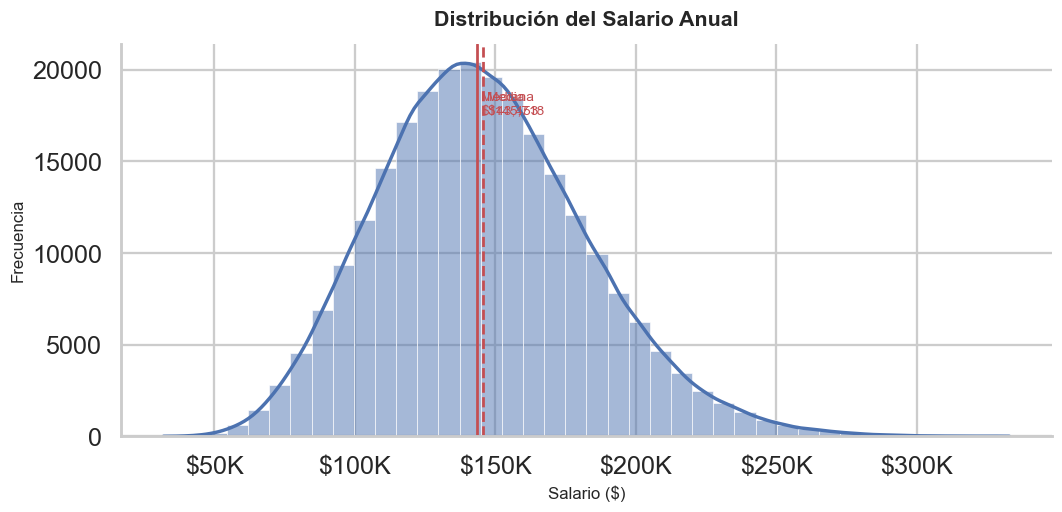

In [4]:
# Estadísticos descriptivos
print(f'Descriptivos: \n{df.describe().round(2)}')
print('-'*40)

# Distribución del salario
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['salary'], kde=True, bins=40,
             color='#4C72B0', edgecolor='white', linewidth=0.4, ax=ax)

media   = df['salary'].mean() # Obtenemos la media
mediana = df['salary'].median() # Obtenemos la mediana
for val, label, ls in [
    (media,   f'Media\n${media:,.0f}',     '--'), # las graficamos ambas
    (mediana, f'Mediana\n${mediana:,.0f}', '-'),
]:
    ax.axvline(val, linestyle=ls, color='#C44E52', linewidth=1.8)
    ax.text(val + 1500, ax.get_ylim()[1] * 0.82, label,
            color='#C44E52', fontsize=9, ha='left') 

ax.set_title('Distribución del Salario Anual', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Salario ($)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación:** Presenta una distribución con un **ligero sesgo a la derecha** (media 145,718 USD > mediana 143,453 USD). El rango es amplio (desde **31.867 USD** hasta **333.046 USD**) con una desviación estándar de **37,408 USD**, lo que indica suficiente variabilidad para que el modelo pueda aprender patrones estadísticos presentes.

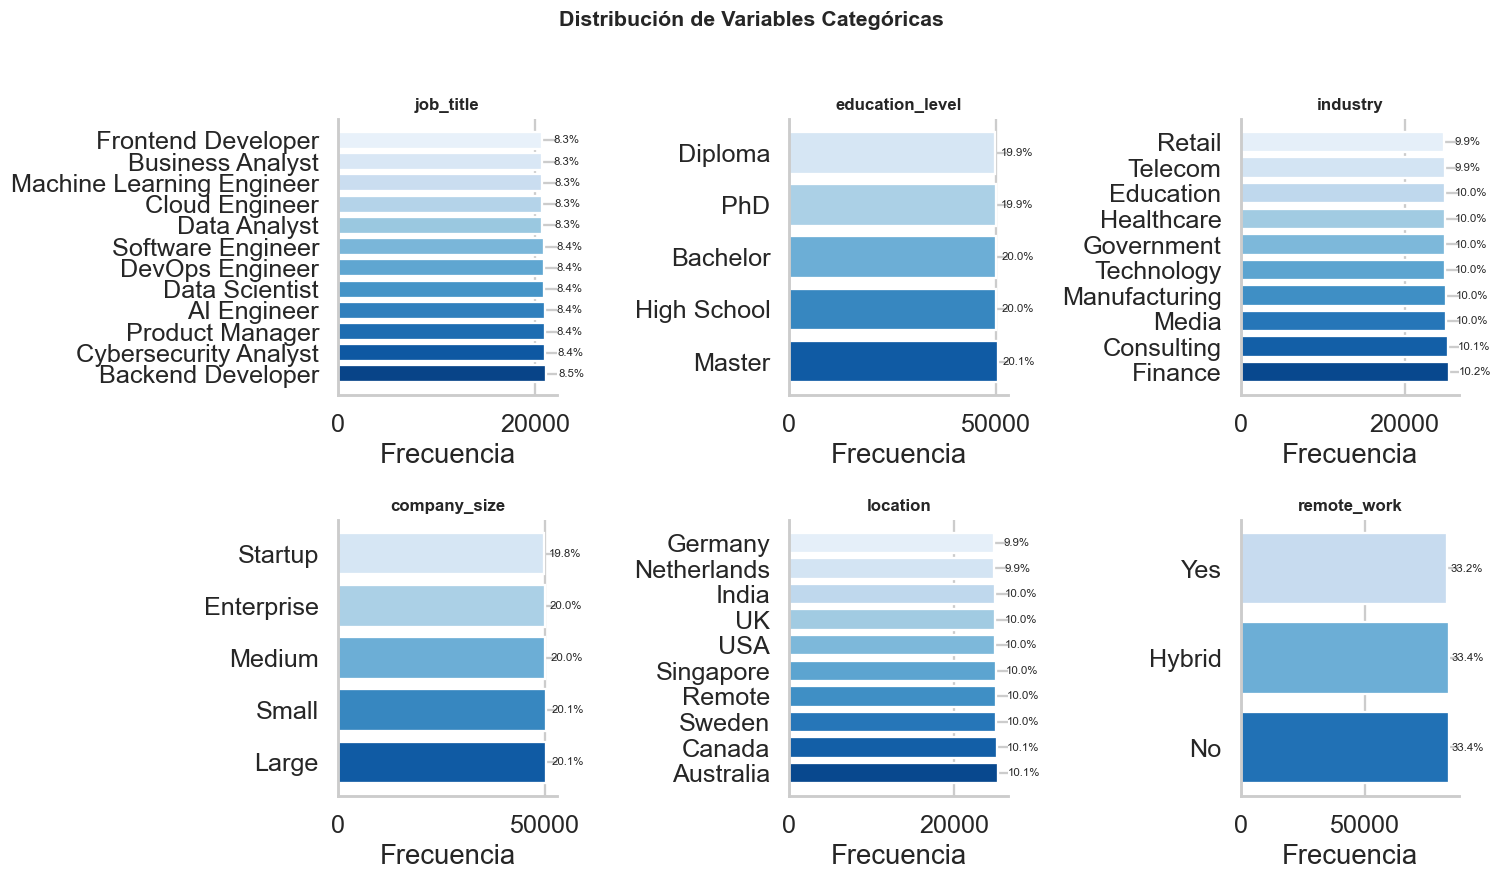

In [5]:
# Distribución de variables categóricas
categoricas = df.select_dtypes(['object', 'string']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    counts = df[col].value_counts()
    bars = axes[i].barh(counts.index, counts.values,
                        color=sns.color_palette('Blues_r', len(counts)),
                        edgecolor='white')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Frecuencia')
    total = counts.sum()
    for bar, v in zip(bars, counts.values):
        axes[i].text(v + total * 0.005, bar.get_y() + bar.get_height() / 2,
                     f'{v/total:.1%}', va='center', fontsize=7.5)

plt.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold', y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación breve:** Las variables categóricas presentan una distribución prácticamente **uniforme**: cada puesto representa 8.3%, cada nivel educativo 20%, cada industria 10% (pasa lo mismo con el resto de categorías: `company_size`-20%, `location`-10%, `remote_work`-33%). Este comportamiento confirma que la base de datos es sintética.

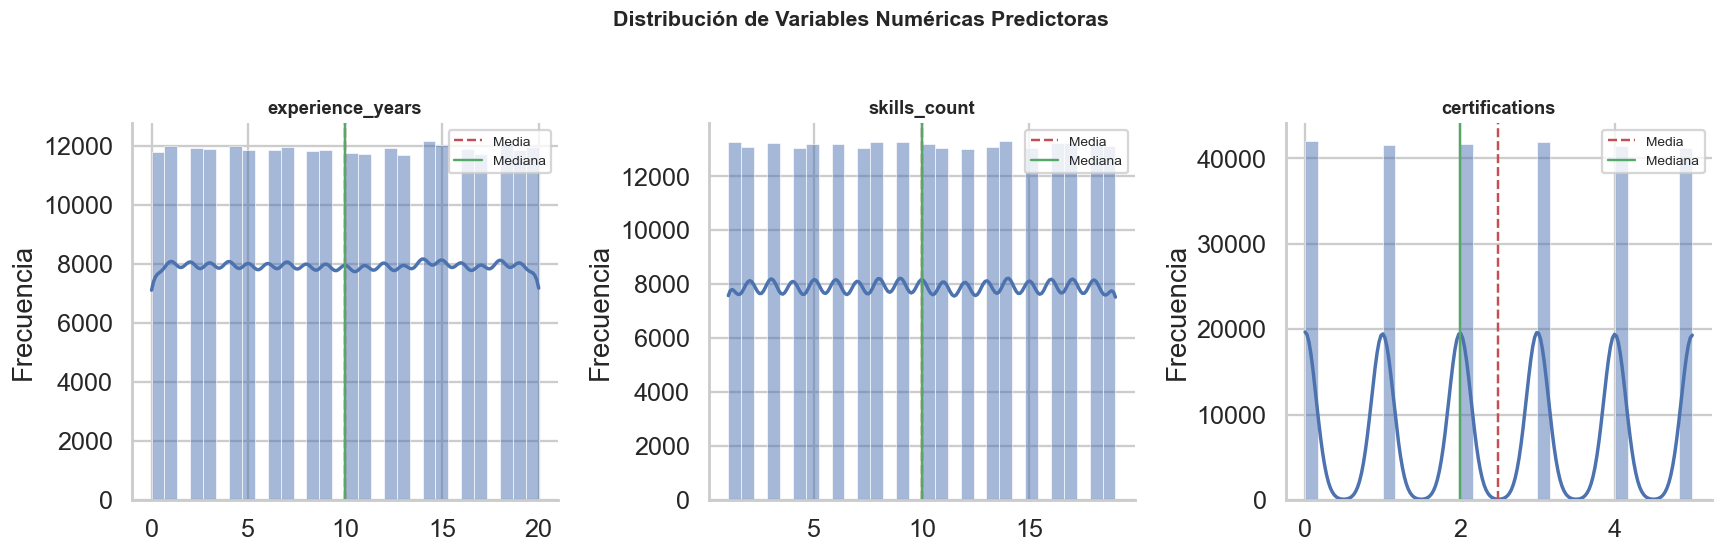

In [6]:
# Distribución vars numéricas predictoras
numericas_pred = ['experience_years', 'skills_count', 'certifications']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numericas_pred):
    sns.histplot(df[col], bins=30, kde=True, color='#4C72B0',
                 edgecolor='white', linewidth=0.4, ax=ax)
    ax.axvline(df[col].mean(),   color='#C44E52', linestyle='--', linewidth=1.6, label='Media')
    ax.axvline(df[col].median(), color='#55A868', linestyle='-',  linewidth=1.6, label='Mediana')
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas Predictoras',
             fontsize=14, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación:** Las tres variables predictoras presentan distribuciones prácticamente **uniformes y simétricas**, con media y mediana prácticamente coincidentes en el punto central de su rango (`experience_years` ≈ 10, `skills_count` ≈ 10, `certifications` ≈ 2.5).

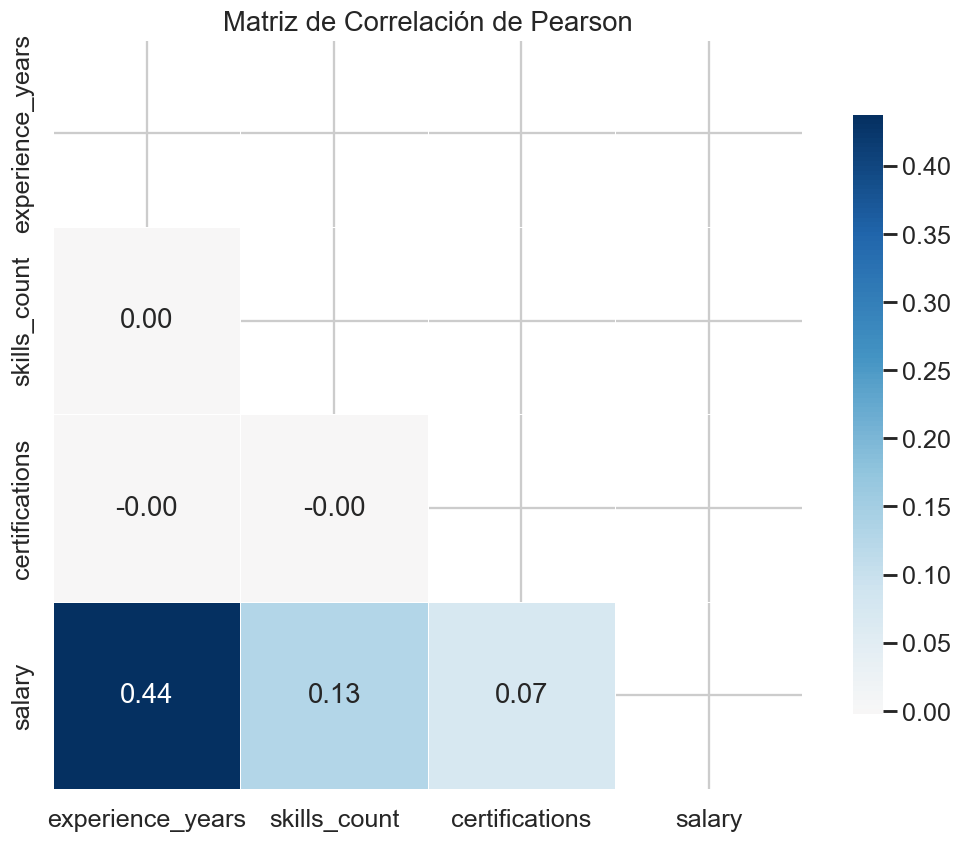

In [7]:
# Matriz de correlación entre variables numéricas
numericas = df.select_dtypes(['int64', 'float64']).columns.tolist()

plt.figure(figsize=(10, 8))
correlation = df[numericas].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, cmap='RdBu', fmt=".2f",
            center=0, mask=mask, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Pearson')
plt.tight_layout(); plt.show()

**Interpretación breve:** La matriz de correlación nos muestra correlaciones **muy bajas** entre todas las variables numéricas (ninguna supera >0.5 con `salary`). Es decir, la variable con mayor correlación (que tampoco es exagerada-0.44) es `experience_year`(0.13), seguido de `skills_count`(0.07). Esto recalca nuestra sospecha de que estamos tratando con una base de datos sintética, en la que en la mayoría de casos las relaciones con la variable objetivo tienden a obtenerse mediante relaciones no lineales. Es por ello, que será muy importante la sección 'D. FEATURE ENGINEERING'

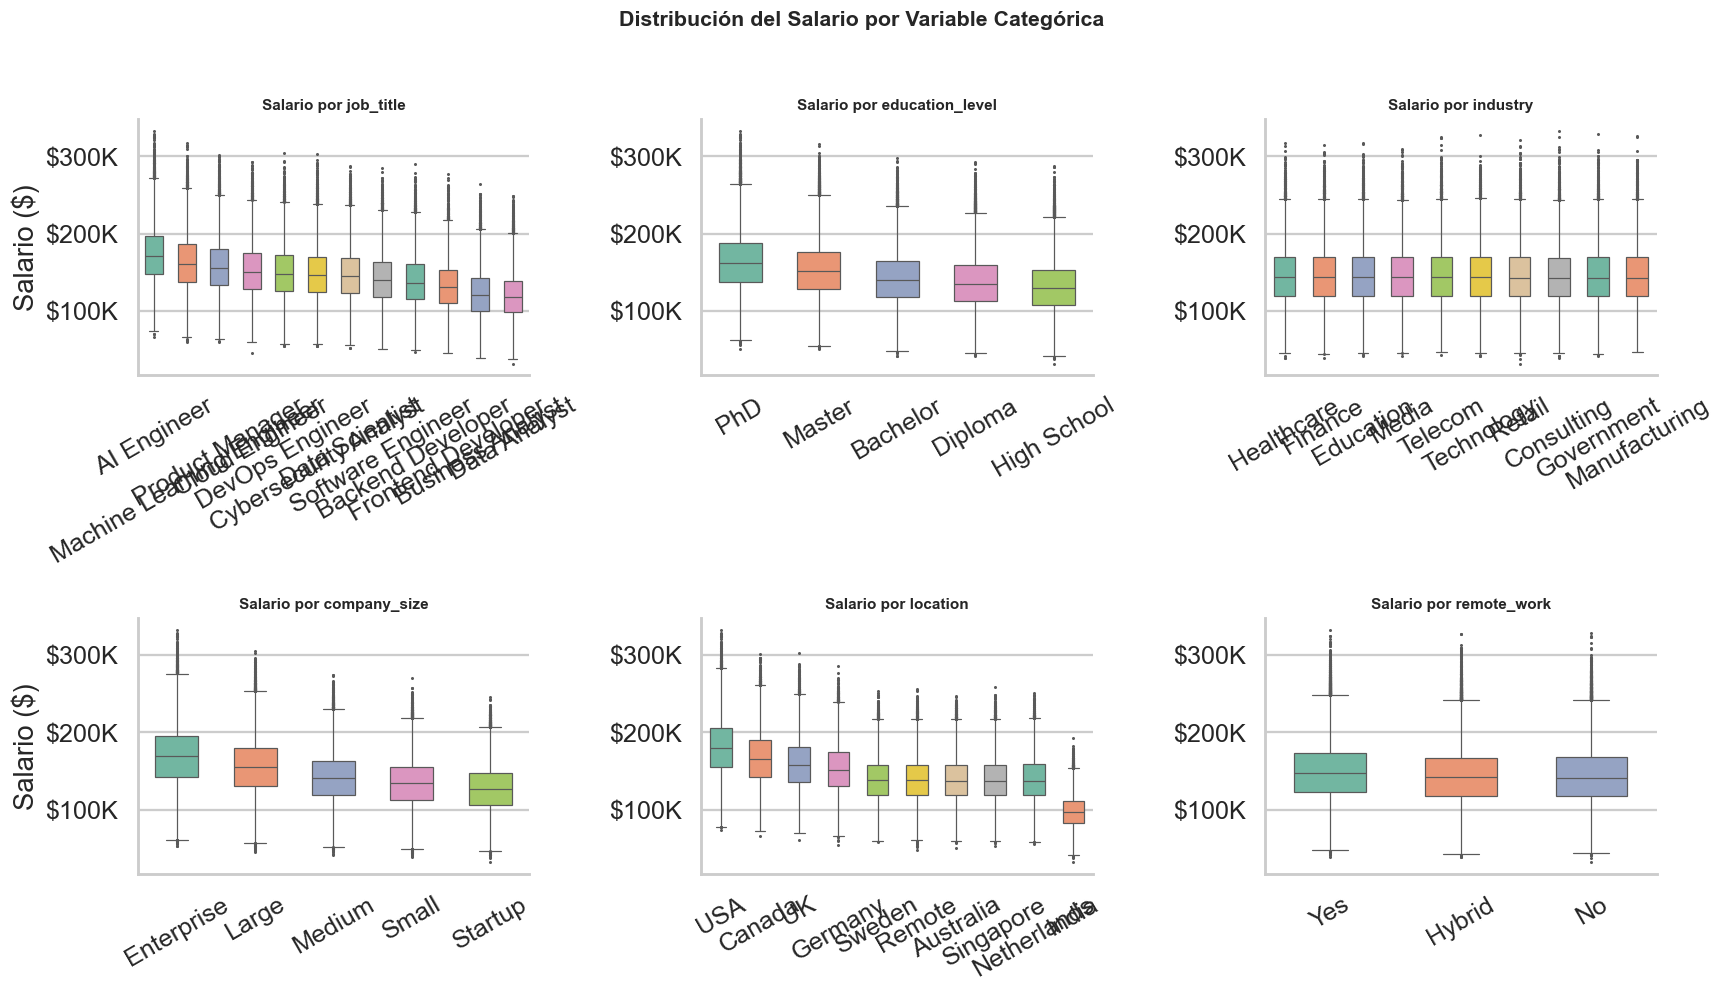

In [8]:
# Distribución del salario por variable categórica
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    order = df.groupby(col)['salary'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='salary', order=order, ax=axes[i],
                palette='Set2', width=0.55, fliersize=1, linewidth=0.8)
    axes[i].set_title(f'Salario por {col}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Salario ($)' if i % 3 == 0 else '')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribución del Salario por Variable Categórica',
             fontsize=14, fontweight='bold', y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación:** Los boxplots revelan algunos patrones como:

- **`job_title`:** Roles de IA/ML (`AI Engineer`, `ML Engineer`, `Data Scientist`) presentan medianas salariales superiores. 
- **`education_level`:** Existe una diferencia positiva con el nivel educativo, a medida que el nivel educativo decrece las medianas de los salarios se comportan igual.
- **`company_size`:** Empresas `Enterprise` y `Large` tienden a pagar más, siguen el mismo comportamiento que `education_level`.
- **`location`:** Los países de habla inglesa (USA/UK) presentan medianas superiores respecto al resto de países; Mientras que India la más baja.
- **`industry`:** `Finance` y `Technology` destacan sobre el resto (en el orden) pero el salario aparentemente no tiene grandes diferencias.
- **`remote_work`:** Diferencias menores; el trabajo remoto muestra una leve superioridad salarial pero ínfima.

### Hallazgos del análisis visual de distribuciones

- **Distribuciones Univariantes Numéricas:** Las tres variables predictoras (`experience_years`, `skills_count`, `certifications`) presentan distribuciones **uniformes y simétricas**, con medias exactamente centradas en sus rangos (0-20, 1-19 y 0-5 respectivamente).

- **Distribuciones Univariantes Categóricas:** Los countplots muestran frecuencias **idénticas** entre todas las categorías (~8.3% por `job_title`, ~20% por `education_level`, ~10% por `industry`, ~20% por `company_size`, ~10% por `location` y ~33% por `remote_work`). Esta distribución es una señal de que la base de datos es síntetica y elimina la necesidad de técnicas de sobremuestreo (SMOTE) o ponderación de clases (class_weiht).

- **Relaciones Numéricas con el Salario (Scatter + Regresión):** Los scatter plots revelan tendencias positivas para `experience_years`, `skills_count` y `certifications` respecto al `salary`. Sin embargo, la **alta dispersión** en todos los gráficos indica que las variables numéricas por sí solas explican muy poco de la varianza salarial, apuntando a que las variables categóricas son **variables más determinantes** para el salario.

- **Mapa de Correlaciones:** El mapa de calor confirma **correlaciones bajas entre los predictores numéricos**, lo que nos indica que en modelos lineales la multicolinealidad debería ser mínima. Las correlaciones de cada variable con `salary` son positivas pero débiles. Por lo que los **modelos basados en árboles** (Random Forest, Gradient Boosting) capturarán mejor las interacciones entre variables categóricas y el salario.

- **Implicación para el Modelo:** Será clave un buen proceso de FEATURE ENGINEERING: Ya sea el uso de `OrdinalEncoder` para variables con orden natural (`education_level`, `company_size`) y `OneHotEncoder` para el resto (`job_title`, `industry`, `location`, `remote_work`). Además, escalar las variables numéricas para modelos sensibles a la escala (SVR, KNN, LinearRegression). Además de la creación de nuevas variables que puedan contener relaciones no lineales que exlicen la variable objetivo `salary`.

### Recap — Sección C

| Análisis | Hallazgo clave |
|---|---|
| Distribución salario | Ligero sesgo derecho (media > mediana); rango $31K–$333K; σ = $37K |
| Variables categóricas | Distribución perfectamente uniforme → Base de datos sintética balanceada |
| Correlaciones | Muy bajas (< 0.5), las relaciones no lineales y categóricas dominan la objetivo|
| Consistencia datos | No existen nulos, no se requiere imputar|
| Salario por categoría | Diferencias moderadas; roles IA/ML y empresas grandes pagan más |
| Implicación modelado | No requiere transformar la target|

In [9]:
# Análisis de outliers con IQR
print('Análisis de outliers por variable numérica:')
print('-'*40)

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = len(outliers) / len(df) * 100
    print(f'{col}: {len(outliers)} outliers ({pct:.1f}%)')

Análisis de outliers por variable numérica:
----------------------------------------
experience_years: 0 outliers (0.0%)
skills_count: 0 outliers (0.0%)
certifications: 0 outliers (0.0%)
salary: 2336 outliers (0.9%)


### Hallazgos del análisis de outliers (IQR)

- **Variables Predictoras sin Outliers:** El método IQR confirma que `experience_years`, `skills_count` y `certifications` presentan **0 outliers**. Sus rangos reales (0-20, 1-19 y 0-5) quedan completamente contenidos dentro de los límites, lo cual es coherente con lo observado en el análisis descriptivo: sus medias se centran exactamente en la mitad de sus rangos.

- **Variable Objetivo con Outliers en Cola Alta:** La variable `salary` registra **2,336 outliers (0.9%)**, todos en el extremo superior: valores que superan el límite IQR de 244.694 y alcanzan el máximo de 333.046. Este resultado es consistente con el **sesgo positivo leve** ya identificado en el EDA (media 145,718 USD > mediana 143,453 USD) y con la cola derecha visible en el histograma de distribución salarial, lo que esta relacionado con individuos que por ciertas características tienen un salario mayor.

- **Naturaleza de los Outliers:** Los salarios extremos no son errores de medición sino obs **válidas** en cualquier mercado laboral: individuos de alta formación, responsabilidades directivas o sectores con alta demanda retributiva (tier 1) generan naturalmente retribuciones alejadas de la mediana.

- **Implicación para el Modelo:** No se aplicará ningún tratamiento de outliers. Eliminar o recortar estas 2.336 obs introduciría **sesgo** hacia el rango salarial medio-bajo, degradando la capacidad predictiva del modelo en los tramos altos.

Análisis de relaciones no lineales con Salary
--------------------------------------------------


,Pearson,Spearman,Mutual Information
Variable,,,
experience_years,0.4376,0.4379,0.1073
skills_count,0.1273,0.1252,0.0074
certifications,0.0738,0.0720,0.0023


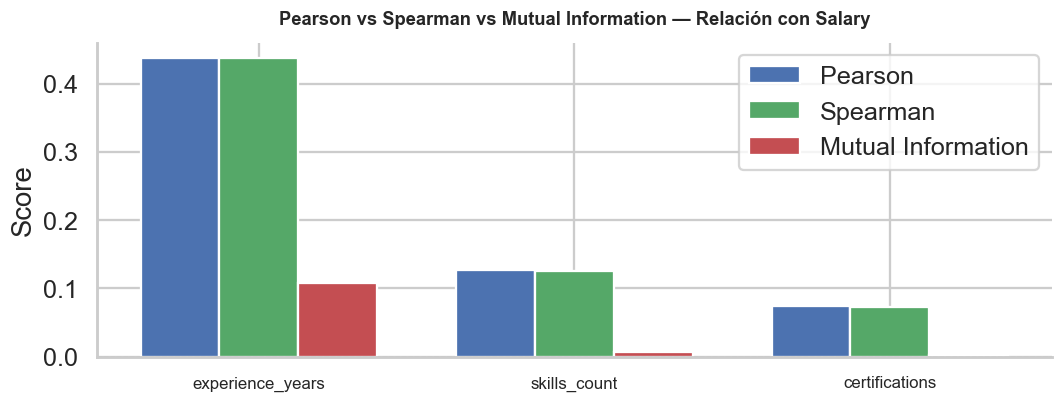

In [10]:
# Correlación de Spearman (relaciones no lineales con salary)
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr

numericas_eval = ['experience_years', 'skills_count', 'certifications']

# Spearman (captura relaciones monótonas, no solo lineales)
spearman_corrs = {col: spearmanr(df[col], df['salary']).statistic for col in numericas_eval}

# Mutual Information (captura cualquier dependencia estadística)
mi_scores = mutual_info_regression(df[numericas_eval], df['salary'], random_state=seed)

relaciones = pd.DataFrame({
    'Variable'           : numericas_eval,
    'Pearson'            : [df[numericas_eval].corrwith(df['salary'])[c] for c in numericas_eval],
    'Spearman'           : list(spearman_corrs.values()),
    'Mutual Information' : mi_scores
}).set_index('Variable').round(4)

print('Análisis de relaciones no lineales con Salary')
print('-' * 50)
display(relaciones)

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(numericas_eval))
width = 0.25

ax.bar(x - width, relaciones['Pearson'],            width, label='Pearson',            color='#4C72B0')
ax.bar(x,         relaciones['Spearman'],            width, label='Spearman',           color='#55A868')
ax.bar(x + width, relaciones['Mutual Information'],  width, label='Mutual Information', color='#C44E52')

ax.set_xticks(x)
ax.set_xticklabels(numericas_eval, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Pearson vs Spearman vs Mutual Information — Relación con Salary',
             fontweight='bold', fontsize=12, pad=12)
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación:** La comparativa entre Pearson, Spearman y Mutual Information revela que las relaciones entre los predictores numéricos y `salary` son débiles pero **consistentemente positivas** en los tres métodos. La MI baja confirma que las variables numéricas por sí solas explican poca varianza del salario, justificando la creación de variables que capturen interacción y el uso de modelos no lineales (árboles). El hecho de que Spearman sea similar a Pearson indica que tampoco hay relaciones monótonas fuertes ocultas.

### D. FEATURE ENGINEERING

A partir de las variables originales creamos nuevas características que capturen relaciones no lineales y contexto de negocio:

| Feature | Descripción |
|---|---|
| `experience_level` | Discretización en 4 tramos (junior/mid/senior/expert) |
| `total_credentials` | Skills + certificaciones — capital humano total |
| `skills_per_year` | Ratio de habilidades por año de experiencia |
| `career_efficiency` | Eficiencia de carrera: ratio entre credenciales totales y nivel educativo |
| `high_demand_role` | Indicador binario: roles IA/ML/Cloud de alta demanda |
| `is_remote` | Indicador binario: trabajo 100% remoto |
| `company_size_ord` | Tamaño de empresa como variable ordinal numérica |
| `edu_level_ord` | Nivel educativo como variable ordinal numérica |
| `high_salary_industry` | Indicador binario: Finance/Technology/Consulting |
| `location_tier` | Jerarquía geográfica salarial (0=bajo, 1=medio, 2=alto) |
| `edu_investment_index` | Índice de inversión educativa: cruce de país por nivel educativo |
| `geo_leverage` | Arbitraje geográfico: roles en remoto y de alta demanda desde países de costo medio/bajo |
| `startup_potential` | Potencial de emprendimiento: ubicación en hub tecnológico × empresa pequeña/startup |
| `overqualification_index` | Sobrecalificación: diferencia entre educación propia y la media de la industria |
| `exp_x_skills` | Interacción: experiencia × habilidades |
| `exp_x_edu` | Interacción: experiencia × nivel educativo |
| `job_category` | Agrupación: Áreas que comparten rangos salariales y habilidades técnicas similares |
| `remote_industry` | Interacción: trabajo 100% remoto × industria |

In [11]:
df_fe = df.copy()  # copia de fe para no alterar el original

# Discretización de experiencia en 4 tramos (captura efectos no lineales)
df_fe['experience_level'] = pd.cut(df_fe['experience_years'], bins=[-1, 3, 7, 13, 20], labels=['junior', 'mid', 'senior', 'expert'])

# Capital humano total: habilidades + certificaciones
df_fe['total_credentials'] = df_fe['skills_count'] + df_fe['certifications']

# Tasa de habilidades por año de experiencia
df_fe['skills_per_year'] = df_fe['skills_count'] / (df_fe['experience_years'] + 1)

# Bin: rol de alta demanda salarial en el mercado tech actual
df_fe['high_demand_role'] = df_fe['job_title'].isin({'AI Engineer', 'Machine Learning Engineer', 'Data Scientist', 'Cloud Engineer'}).astype(int)

# Bin: trabajo 100% remoto (tiende a asociarse con salarios superiores)
df_fe['is_remote'] = (df_fe['remote_work'] == 'Yes').astype(int)

# Tamaño de empresa ordinal 
size_dtype = pd.CategoricalDtype(categories=['Startup', 'Small', 'Medium', 'Large', 'Enterprise'], ordered=True)
df_fe['company_size_ord'] = df_fe['company_size'].astype(size_dtype).cat.codes 

# Nivel educativo ordinal
edu_dtype = pd.CategoricalDtype(categories=['High School', 'Diploma', 'Bachelor', 'Master', 'PhD'], ordered=True)
df_fe['edu_level_ord'] = df_fe['education_level'].astype(edu_dtype).cat.codes

# Bin: industria de alto salario histórico
df_fe['high_salary_industry'] = df_fe['industry'].isin({'Finance', 'Technology', 'Consulting'}).astype(int)

# Interacción experiencia × habilidades
df_fe['exp_x_skills'] = df_fe['experience_years'] * df_fe['skills_count']

# Interacción experiencia × educación
df_fe['exp_x_edu'] = df_fe['experience_years'] * df_fe['edu_level_ord']

# Rango de ubicación por nivel salarial de mercado (2=alto, 1=medio, 0=bajo)
df_fe['location_tier'] = df_fe['location'].map({
    'USA': 2, 'UK': 2, 'Australia': 2, 'Germany': 2, 'Netherlands': 2,
    'Canada': 1, 'Sweden': 1, 'Singapore': 1, 'India': 0, 'Remote': 0
}).fillna(0)

# Índice de inversión educativa (País x Nivel educativo)
costo_edu = {'USA': 1.5, 'UK': 1.3, 'Australia': 1.3, 'Canada': 1.2, 'Germany': 0.7, 'Netherlands': 0.8, 'Sweden': 0.7, 'India': 0.5, 'Singapore': 1.1}
df_fe['edu_investment_index'] = df_fe['edu_level_ord'] * df_fe['location'].map(costo_edu).fillna(1.0)

# Sobrecalificación (Diferencia entre tu educación y la media de tu industria)
df_fe['overqualification_index'] = df_fe['edu_level_ord'] - df_fe.groupby('industry')['edu_level_ord'].transform('mean')

# Arbitraje geográfico (Individuos en remoto, con roles de alta demanda y viviendo en países costo medio/bajo)
df_fe['geo_leverage'] = ((df_fe['is_remote'] == 1) & (df_fe['high_demand_role'] == 1) & (df_fe['location_tier'] < 2)).astype(int)

# Eficiencia de carrera
df_fe['career_efficiency'] = df_fe['total_credentials'] / (df_fe['edu_level_ord'] + 1)

# Interacción Remoto e Industria
df_fe['remote_industry'] = df_fe['remote_work'] + "_" + df_fe['industry']

# Potencial de emprendimiento
hubs = ['USA', 'UK', 'Singapore', 'India', 'Netherlands']
df_fe['startup_potential'] = ((df_fe['location'].isin(hubs)) & (df_fe['company_size'].isin(['Startup', 'Small']))).astype(int)

# Agrupacion trabajos vía grupos
mapeo_roles = {
    'AI Engineer': 'Data Science & AI', 'Machine Learning Engineer': 'Data Science & AI', 'Data Scientist': 'Data Science & AI',
    'Data Analyst': 'Data & Analytics', 'Business Analyst': 'Data & Analytics',
    'Frontend Developer': 'Software Development', 'Backend Developer': 'Software Development', 'Software Engineer': 'Software Development',
    'DevOps Engineer': 'Infrastructure & Security', 'Cloud Engineer': 'Infrastructure & Security', 'Cybersecurity Analyst': 'Infrastructure & Security',
    'Product Manager': 'Management'
}
df_fe['job_category'] = df_fe['job_title'].map(mapeo_roles)

new_features = [
    'experience_level', 'total_credentials', 'skills_per_year', 'career_efficiency',
    'high_demand_role', 'is_remote', 'high_salary_industry', 'location_tier', 
    'edu_investment_index', 'geo_leverage', 'startup_potential', 
    'overqualification_index', 'exp_x_skills', 'exp_x_edu', 'job_category', 'remote_industry'
]

print(f'Shape original : {df.shape}')
print(f'Shape con FE   : {df_fe.shape}')
print()
print(f'Variables totales creadas: {len(new_features)}')
print('Muestra de las nuevas features:')
df_fe[new_features].head(10)

Shape original : (250000, 10)
Shape con FE   : (250000, 28)

Variables totales creadas: 16
Muestra de las nuevas features:


,experience_level,total_credentials,skills_per_year,career_efficiency,high_demand_role,is_remote,high_salary_industry,location_tier,edu_investment_index,geo_leverage,startup_potential,overqualification_index,exp_x_skills,exp_x_edu,job_category,remote_industry
0,senior,4,0.181818,1.333333,1,0,0,0,1.0,0,0,-0.004137,20,20,Data Science & AI,Hybrid_Healthcare
1,mid,17,2.833333,5.666667,0,0,0,2,2.6,0,0,-0.005270,85,10,Data & Analytics,No_Telecom
2,expert,5,0.210526,1.000000,0,0,0,1,4.4,0,0,1.997763,72,72,Software Development,No_Media
3,expert,13,0.650000,2.600000,0,1,0,1,4.8,0,0,1.995089,247,76,Data & Analytics,Yes_Retail
4,expert,7,0.437500,2.333333,0,1,0,1,1.4,0,0,0.003836,105,30,Management,Yes_Manufacturing
5,junior,6,4.000000,6.000000,1,0,0,2,0.0,0,0,-2.003737,0,0,Data Science & AI,No_Education
6,mid,19,2.285714,19.000000,0,0,0,1,0.0,0,0,-1.996164,96,0,Software Development,No_Manufacturing
7,mid,23,3.600000,7.666667,1,0,0,1,2.4,0,0,-0.004137,72,8,Data Science & AI,Hybrid_Healthcare
8,mid,14,2.333333,7.000000,1,1,0,1,1.1,1,0,-1.005270,70,5,Data Science & AI,Yes_Telecom
9,expert,7,0.105263,1.400000,0,0,0,0,2.0,0,0,1.995089,36,72,Software Development,Hybrid_Retail


Ranking de poder predictivo — Originales vs Features Engineered


,Feature,Tipo,MI Score,Spearman (abs)
0,edu_investment_index,Nueva FE,0.1922,0.4165
1,exp_x_edu,Nueva FE,0.1374,0.4465
2,experience_years,Original,0.1072,0.4379
3,company_size_ord,Nueva FE,0.0920,0.3900
4,exp_x_skills,Nueva FE,0.0905,0.3928
5,location_tier,Nueva FE,0.0836,0.3148
6,skills_per_year,Nueva FE,0.0606,0.2132
7,overqualification_index,Nueva FE,0.0516,0.2942
8,edu_level_ord,Nueva FE,0.0482,0.3002
9,career_efficiency,Nueva FE,0.0363,0.1079


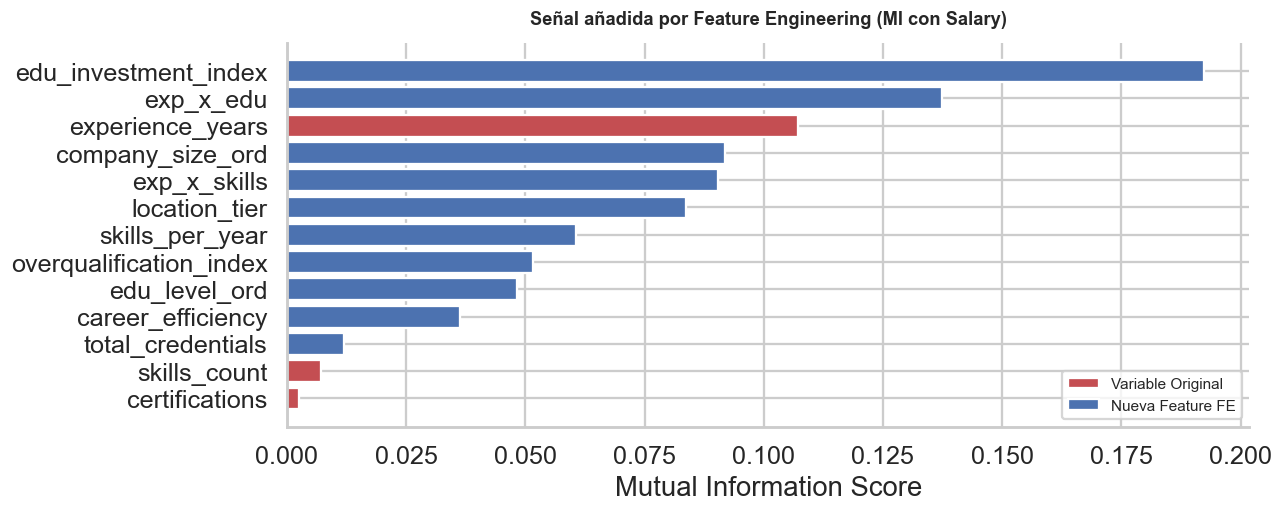

In [12]:
# Validación del Feature Engineering ¿añaden poder predictivod real?
from sklearn.feature_selection import mutual_info_regression

# Variables originales numéricas vs nuevas features numéricas
features_originales = ['experience_years', 'skills_count', 'certifications']

features_nuevas_num = [
    'total_credentials', 'skills_per_year', 'career_efficiency',
    'exp_x_skills', 'exp_x_edu', 'edu_investment_index',
    'overqualification_index', 'location_tier', 'company_size_ord',
    'edu_level_ord'
]

todas = features_originales + features_nuevas_num
X_eval = df_fe[todas].copy()

mi_scores = mutual_info_regression(X_eval, df_fe['salary'], random_state=seed)
spearman_scores = [abs(df_fe[col].corr(df_fe['salary'], method='spearman')) for col in todas]

validacion_fe = pd.DataFrame({
    'Feature'            : todas,
    'Tipo'               : ['Original'] * len(features_originales) + ['Nueva FE'] * len(features_nuevas_num),
    'MI Score'           : mi_scores,
    'Spearman (abs)'     : spearman_scores
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print('Ranking de poder predictivo — Originales vs Features Engineered')
display(validacion_fe.round(4))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 5))
colores = validacion_fe['Tipo'].map({'Original': '#C44E52', 'Nueva FE': '#4C72B0'})
bars = ax.barh(validacion_fe['Feature'], validacion_fe['MI Score'],
               color=colores, edgecolor='white')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Señal añadida por Feature Engineering (MI con Salary)',
             fontweight='bold', fontsize=12, pad=12)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C44E52', label='Variable Original'),
                   Patch(facecolor='#4C72B0', label='Nueva Feature FE')]
ax.legend(handles=legend_elements, fontsize=10)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

### Recap — Sección D

| Variable | Tipo | Justificación |
|---|---|---|
| `experience_level` | Discretización | Captura efectos no lineales por tramos de carrera |
| `total_credentials` | Agregación | Capital humano total (skills + certs) |
| `skills_per_year` | Ratio | Velocidad de acumulación de habilidades |
| `career_efficiency` | Ratio | Rendimiento de credenciales por nivel educativo |
| `high_demand_role` | Binaria | Roles IA/ML/Cloud con prima salarial de mercado |
| `is_remote` | Binaria | Asociación con salarios superiores |
| `high_salary_industry` | Binaria | Industrias tier-1 (Finance, Tech, Consulting) |
| `location_tier` | Ordinal | Jerarquía geográfica salarial (0-2) |
| `edu_investment_index` | Interacción | País × educación → **variable #top 1 por MI (0.1922)** |
| `overqualification_index` | Diferencial | Distancia entre educación propia y media de industria |
| `geo_leverage` | Combinada | Arbitraje: remoto + alta demanda + país costo bajo |
| `startup_potential` | Combinada | Hub tecnológico × empresa pequeña/startup |
| `exp_x_skills` | Interacción multiplicativa | Experiencia × habilidades — MI: 0.0905 |
| `exp_x_edu` | Interacción multiplicativa | Experiencia × nivel educativo — **MI: 0.1374, #2 overall** |
| `job_category` | Agrupación | Roles con salarios y skills similares |
| `remote_industry` | Interacción categórica | Remoto × industria (30 combinaciones → OHE) |

**Resultado MI:** El Feature Engineering ha sido **efectivo**. Las dos variables con mayor poder predictivo de la base de datos completa son ambas de nueva creación: `edu_investment_index` (MI=0.1922) y `exp_x_edu` (MI=0.1374), superando a `experience_years` original (MI=0.1072). Las tres variables originales numéricas ocupan las posiciones #3, #12 y #13 del ranking, confirmando que el proceso de FE ha añadido señal estadística real y justifica el esfuerzo de ingeniería de características.

### E. PROCESO PREDICTIVO: PREPROCESADO-MODELADO-SELECCIÓN

Desarrollare todo el proceso predictivo de principio a fin

In [13]:
cols_eliminar = ['salary', 'job_title', 'location', 'industry', 'remote_work', 'company_size_ord', 'edu_level_ord']
X = df_fe.drop(cols_eliminar, axis = 1)
y = df_fe['salary']
print('-'*40)
print(f'Variables predictoras: \n{list(X.columns)}')
print(f'Variable objetivo: \n{y}')
print('-'*40)
print(f'Tamaño de X: \nFilas:{X.shape[0]} | Columnas: {X.shape[1]}')

----------------------------------------
Variables predictoras: 
['experience_years', 'education_level', 'skills_count', 'company_size', 'certifications', 'experience_level', 'total_credentials', 'skills_per_year', 'high_demand_role', 'is_remote', 'high_salary_industry', 'exp_x_skills', 'exp_x_edu', 'location_tier', 'edu_investment_index', 'overqualification_index', 'geo_leverage', 'career_efficiency', 'remote_industry', 'startup_potential', 'job_category']
Variable objetivo: 
0         109413
1          93764
2         148123
3         189123
4         165069
           ...  
249995    127791
249996    154593
249997     75988
249998     90467
249999    133084
Name: salary, Length: 250000, dtype: int64
----------------------------------------
Tamaño de X: 
Filas:250000 | Columnas: 21


In [14]:
# Split en tr/te
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.3,
                                                    random_state = seed)
print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

numericas = X.select_dtypes(['int64', 'float64']).columns.tolist()
binarias = ['high_demand_role', 'is_remote', 'high_salary_industry', 'geo_leverage', 'startup_potential']
numericas = [c for c in numericas if c not in binarias]

ordinales = ['company_size', 'education_level', 'experience_level']
categoricas = [c for c in X.columns
                if c not in numericas and c not in ordinales and c not in binarias]
orden_ordinal = {
    'company_size' : ['Startup', 'Small', 'Medium', 'Large', 'Enterprise'],
    'education_level' : ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD'],
    'experience_level': ['junior', 'mid', 'senior', 'expert']
}

print('-'*40)
print(f'Numéricas: \n{numericas}')
print('-'*40)
print(f'Binarias: \n{binarias}')
print('-'*40)
print(f'Ordinales: \n{ordinales}')
print('-'*40)
print(f'Nominales: \n{categoricas}')

preprocesado = ColumnTransformer([
    ('numericas', StandardScaler(), numericas),
    ('binarias', 'passthrough', binarias),
    ('categoricas', OneHotEncoder(handle_unknown='ignore',
                                 sparse_output=False), categoricas),
    ('ordinales', OrdinalEncoder(categories=[orden_ordinal[c] for c in ordinales]), ordinales)
])



Train: (175000, 21) | Test: (75000, 21)
----------------------------------------
Numéricas: 
['experience_years', 'skills_count', 'certifications', 'total_credentials', 'skills_per_year', 'exp_x_skills', 'exp_x_edu', 'location_tier', 'edu_investment_index', 'overqualification_index', 'career_efficiency']
----------------------------------------
Binarias: 
['high_demand_role', 'is_remote', 'high_salary_industry', 'geo_leverage', 'startup_potential']
----------------------------------------
Ordinales: 
['company_size', 'education_level', 'experience_level']
----------------------------------------
Nominales: 
['remote_industry', 'job_category']


In [15]:
# Pipeline para ElasticNet
pipeline_elastic = Pipeline([
    ('preprocesado', preprocesado),
    ('modelo', ElasticNet(max_iter=2000, 
                         random_state=seed))
])

scoring = {
    'r2': 'r2',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_rmse': 'neg_root_mean_squared_error',
}

grid_elastic = GridSearchCV(
    estimator=pipeline_elastic,
    param_grid={
        'modelo__alpha': [0.1, 0.5, 1.0, 5.0, 10.0, 20.0], # Cuanto mas grande, mas fuerza tiene la penalización
        'modelo__l1_ratio': [0.9, 0.95, 0.99, 1.0], # Mezcla de penalizaciones
        'modelo__fit_intercept': [True, False] # Si calcula el intercepto
    },
    scoring=scoring,
    refit='r2', # Optimizamos en base al mejor R2
    cv=5,       # 5 folds para la validación cruzada
    n_jobs=-1,  # Utilizar todos los núcleos
    verbose=1, 
)

# Entrenamos el pipeline
#grid_elastic.fit(X_train, y_train)

# Generamos y analizamos los resultados
#results_elastic = pd.DataFrame(grid_elastic.cv_results_)
#results_elastic = results_elastic.sort_values('mean_test_r2', ascending=False).reset_index(drop=True)

# Seleccionamos las columnas de los folds para visualizar
#cols_folds = [f'split{i}_test_r2' for i in range(5)]

#m0 = results_elastic[cols_folds].iloc[0]
#m1 = results_elastic[cols_folds].iloc[1]
#m2 = results_elastic[cols_folds].iloc[2]
#m3 = results_elastic[cols_folds].iloc[3]
#m4 = results_elastic[cols_folds].iloc[4]

# Gráfico de cajas
#plt.figure(figsize=(10, 6))
#plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
#            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
#plt.ylabel('R2 por fold')
#plt.title('Estabilidad de los 5 mejores modelos ElasticNet')
#plt.show()
#plt.close()

# Imprimir el top 5
#print('Mejores modelos generales')
#print(results_elastic[['params', 'mean_test_r2']].head(5))
#print('\n Hiperparámetros del top 5')
#columnas_params = [
#    'param_modelo__alpha', 
#    'param_modelo__l1_ratio', 
#    'param_modelo__fit_intercept', 
#    'mean_test_r2'
#]
#print(results_elastic.head(5)[columnas_params])

In [16]:
# Pipeline para KNN
pipeline_knn = Pipeline([
    ('preprocesado', preprocesado),
    ('seleccionador', SelectKBest(score_func=f_regression)),
    ('modelo', KNeighborsRegressor())
])

grid_knn = GridSearchCV(
    estimator=pipeline_knn, 
    param_grid={
        'seleccionador__k': [9, 11, 13, 15], 
        'modelo__n_neighbors': [9, 11, 13, 15, 17],
        'modelo__weights' : ['uniform', 'distance'],
        'modelo__metric' : ['euclidean', 'manhattan'] 
    },
    scoring=scoring,
    refit='r2', 
    cv=5,       
    n_jobs=-1,  
    verbose=1, 
)

# Entrenamos el pipeline
#grid_knn.fit(X_train, y_train)

# Generamos y analizamos los resultados
#results_knn = pd.DataFrame(grid_knn.cv_results_)
#results_knn = results_knn.sort_values('mean_test_r2', ascending=False).reset_index(drop=True)

# Seleccionamos las columnas de los folds para visualizar
#cols_folds = [f'split{i}_test_r2' for i in range(5)]

#m0 = results_knn[cols_folds].iloc[0]
#m1 = results_knn[cols_folds].iloc[1]
#m2 = results_knn[cols_folds].iloc[2]
#m3 = results_knn[cols_folds].iloc[3]
#m4 = results_knn[cols_folds].iloc[4]

# Gráfico de cajas
#plt.figure(figsize=(10, 6))
#plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
#            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
#plt.ylabel('R2 por fold')
#plt.title('Estabilidad de los 5 mejores modelos KNN')
#plt.show()
#plt.close()

# Imprimimos el top 5
#print('Mejores modelos generales')
#print(results_knn[['params', 'mean_test_r2']].head(5))
#print('\n Hiperparámetros del top 5')
#columnas_params = [
#    'param_seleccionador__k',
#    'param_modelo__n_neighbors', 
#    'param_modelo__weights', 
#    'param_modelo__metric', 
#    'mean_test_r2'
#]
#print(results_knn.head(5)[columnas_params])

In [17]:
# Pipeline RandomForest 
pipeline_rf = Pipeline([
    ('preprocesado', preprocesado),
    ('modelo', RandomForestRegressor(
        random_state=seed,
        n_jobs=-1
    ))
])

param_grid_rf = {
    'modelo__max_depth': [None, 25, 30],
    'modelo__min_samples_split': [8, 10, 12],
    'modelo__min_samples_leaf': [3, 4, 5],
    'modelo__max_features': [0.7, 0.8, 0.9]
}

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring=scoring,
    refit='r2', 
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# Entrenamos el pipeline
#grid_rf.fit(X_train, y_train)

# Generamos y analizamos los resultados
#results_rf = pd.DataFrame(grid_rf.cv_results_)
#results_rf = results_rf.sort_values('mean_test_r2', ascending=False).reset_index(drop=True)

# Seleccionamos las columnas de los folds para visualizar
#cols_folds = [f'split{i}_test_r2' for i in range(5)]

#m0 = results_rf[cols_folds].iloc[0]
#m1 = results_rf[cols_folds].iloc[1]
#m2 = results_rf[cols_folds].iloc[2]
#m3 = results_rf[cols_folds].iloc[3]
#m4 = results_rf[cols_folds].iloc[4]

# Gráfico de cajas
#plt.figure(figsize=(10, 6))
#plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
#            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
#plt.ylabel('R2 por fold')
#plt.title('Estabilidad de los 5 mejores modelos RandomForest')
#plt.show()
#plt.close()

# Imprimimos el top 5
#print('Mejores modelos generales')
#print(results_rf[['params', 'mean_test_r2']].head(5))
#print('\n Hiperparámetros del top 5')
#columnas_params_rf = [
#    'param_modelo__max_depth',
#    'param_modelo__min_samples_split',
#    'param_modelo__min_samples_leaf',
#    'param_modelo__max_features',
#    'mean_test_r2'
#]
#print(results_rf.head(5)[columnas_params_rf])


In [18]:
# Pipeline GradientBoosting
pipeline_gb = Pipeline([
    ('preprocesado', preprocesado),
    ('modelo', GradientBoostingRegressor(random_state=seed))
])

param_grid_gb = {
    'modelo__n_estimators': [100, 200],
    'modelo__learning_rate': [0.05, 0.1],
    'modelo__max_depth': [5, 7],
    'modelo__min_samples_leaf': [2, 4],
    'modelo__subsample': [0.8, 1.0],
    'modelo__max_features': [0.8, 1.0]
}


grid_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_grid_gb,
    scoring=scoring,
    refit='r2',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

# Entrenamos el pipeline
#grid_gb.fit(X_train, y_train)

# Generamos y analizamos los resultados
#results_gb = pd.DataFrame(grid_gb.cv_results_)
#results_gb = results_gb.sort_values('mean_test_r2', ascending=False).reset_index(drop=True)

# Seleccionamos las columnas de los folds para visualizar
#cols_folds = [f'split{i}_test_r2' for i in range(5)]

#m0 = results_gb[cols_folds].iloc[0]
#m1 = results_gb[cols_folds].iloc[1]
#m2 = results_gb[cols_folds].iloc[2]
#m3 = results_gb[cols_folds].iloc[3]
#m4 = results_gb[cols_folds].iloc[4]

# Gráfico de cajas
#plt.figure(figsize=(10, 6))
#plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
#            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
#plt.ylabel('R2 por fold')
#plt.title('Estabilidad de los 5 mejores modelos GradientBoosting')
#plt.show()
#plt.close()

# Imprimimos el top 5
#print('Mejores modelos generales')
#print(results_gb[['params', 'mean_test_r2']].head(5))

#print('\n Hiperparámetros del top 5')
#columnas_params_gb = [
#    'param_modelo__n_estimators',
#    'param_modelo__learning_rate',
#    'param_modelo__max_depth',
#    'param_modelo__min_samples_leaf', 
#    'param_modelo__subsample',
#    'param_modelo__max_features',   
#    'mean_test_r2'
#]
#print(results_gb.head(5)[columnas_params_gb])


In [19]:
from sklearn.base import clone

# Defino los hiperparámetros elegidos para cada modelo tras analizar su respectivo top 5
params_elastic = {
    'modelo__alpha' : 10.0, 
    'modelo__l1_ratio': 1.0,
    'modelo__fit_intercept' : True
}

params_knn = {
    'seleccionador__k' : 13,
    'modelo__n_neighbors' : 15,
    'modelo__weights': 'uniform',
    'modelo__metric' : 'manhattan'
}

params_rf = {
    'modelo__max_depth' : 25,
    'modelo__min_samples_split' : 10,
    'modelo__min_samples_leaf' : 4,
    'modelo__max_features' : 0.9
}

params_gb = {
    'modelo__n_estimators' : 200,
    'modelo__learning_rate' : 0.1,
    'modelo__max_depth' : 7,
    'modelo__min_samples_leaf' : 2,
    'modelo__subsample' : 0.8,
    'modelo__max_features': 0.8
}

best_models = {
    'ElasticNet': clone(pipeline_elastic).set_params(**params_elastic),
    'KNN': clone(pipeline_knn).set_params(**params_knn),
    'RandomForest': clone(pipeline_rf).set_params(**params_rf),
    'GradientBoost': clone(pipeline_gb).set_params(**params_gb),
}

# Entreno y evaluo los modelos seleccionados
resultados = []

print('Entrenando modelos seleccionados y calculando métricas...\n')
for nombre, modelo in best_models.items():
    # Entrenar con el conjunto de entrenamiento
    modelo.fit(X_train, y_train)
    
    # Predecir en train y test para evaluar el overfitting
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = root_mean_squared_error(y_test, y_pred_test)
    
    resultados.append({
        'Modelo': nombre,
        'R2 Train': r2_train,
        'R2 Test': r2_test,
        'Dif R2 (Overfit)': r2_train - r2_test,
        'MAE Test': mae_test,
        'RMSE Test': rmse_test
    })

comparativa_final = pd.DataFrame(resultados).sort_values('R2 Test', ascending=False)

print('Comparativa Final de Modelos Seleccionados')
display(comparativa_final)


# Cálculo las diferencias entre modelos para decidir
# Tomo como referencia el mejor modelo (el de la fila 0)
mejor_modelo = comparativa_final.iloc[0]

comparativa_diff = comparativa_final.copy()

# Calculo la diferencia de cada modelo respecto al mejor
comparativa_diff['Pérdida R2 Test'] = comparativa_diff['R2 Test'] - mejor_modelo['R2 Test']
comparativa_diff['Mejora Overfit (R2)'] = comparativa_diff['Dif R2 (Overfit)'] - mejor_modelo['Dif R2 (Overfit)']
comparativa_diff['Dif MAE Test'] = comparativa_diff['MAE Test'] - mejor_modelo['MAE Test']
comparativa_diff['Dif RMSE Test'] = comparativa_diff['RMSE Test'] - mejor_modelo['RMSE Test']

cols_mostrar = [
    'Modelo', 
    'Pérdida R2 Test', 
    'Mejora Overfit (R2)', 
    'Dif MAE Test', 
    'Dif RMSE Test'
]

print('\n' + '-'*60)
print(f'Diferencias respecto al mejor modelo ({mejor_modelo["Modelo"]})')
print('-'*60)
print('* Pérdida R2 Test: Cuánto score perdemos frente al mejor (negativo = peor)')
print('* Mejora Overfit: Cuánto reducimos el sobreajuste frente al mejor (negativo = menos overfitting = mejor)')
print('-'*60)
display(comparativa_diff[cols_mostrar])


Entrenando modelos seleccionados y calculando métricas...

Comparativa Final de Modelos Seleccionados


,Modelo,R2 Train,R2 Test,Dif R2 (Overfit),MAE Test,RMSE Test
3,GradientBoost,0.926407,0.916481,0.009927,8085.639021,10813.154919
2,RandomForest,0.950910,0.898417,0.052493,9124.432600,11925.303167
1,KNN,0.869803,0.850389,0.019414,11260.826655,14472.394042
0,ElasticNet,0.794578,0.793781,0.000797,13454.972332,16991.147339



------------------------------------------------------------
Diferencias respecto al mejor modelo (GradientBoost)
------------------------------------------------------------
* Pérdida R2 Test: Cuánto score perdemos frente al mejor (negativo = peor)
* Mejora Overfit: Cuánto reducimos el sobreajuste frente al mejor (negativo = menos overfitting = mejor)
------------------------------------------------------------


,Modelo,Pérdida R2 Test,Mejora Overfit (R2),Dif MAE Test,Dif RMSE Test
3,GradientBoost,0.000000,0.000000,0.000000,0.000000
2,RandomForest,-0.018064,0.042567,1038.793579,1112.148248
1,KNN,-0.066092,0.009488,3175.187634,3659.239122
0,ElasticNet,-0.122699,-0.009130,5369.333311,6177.992420


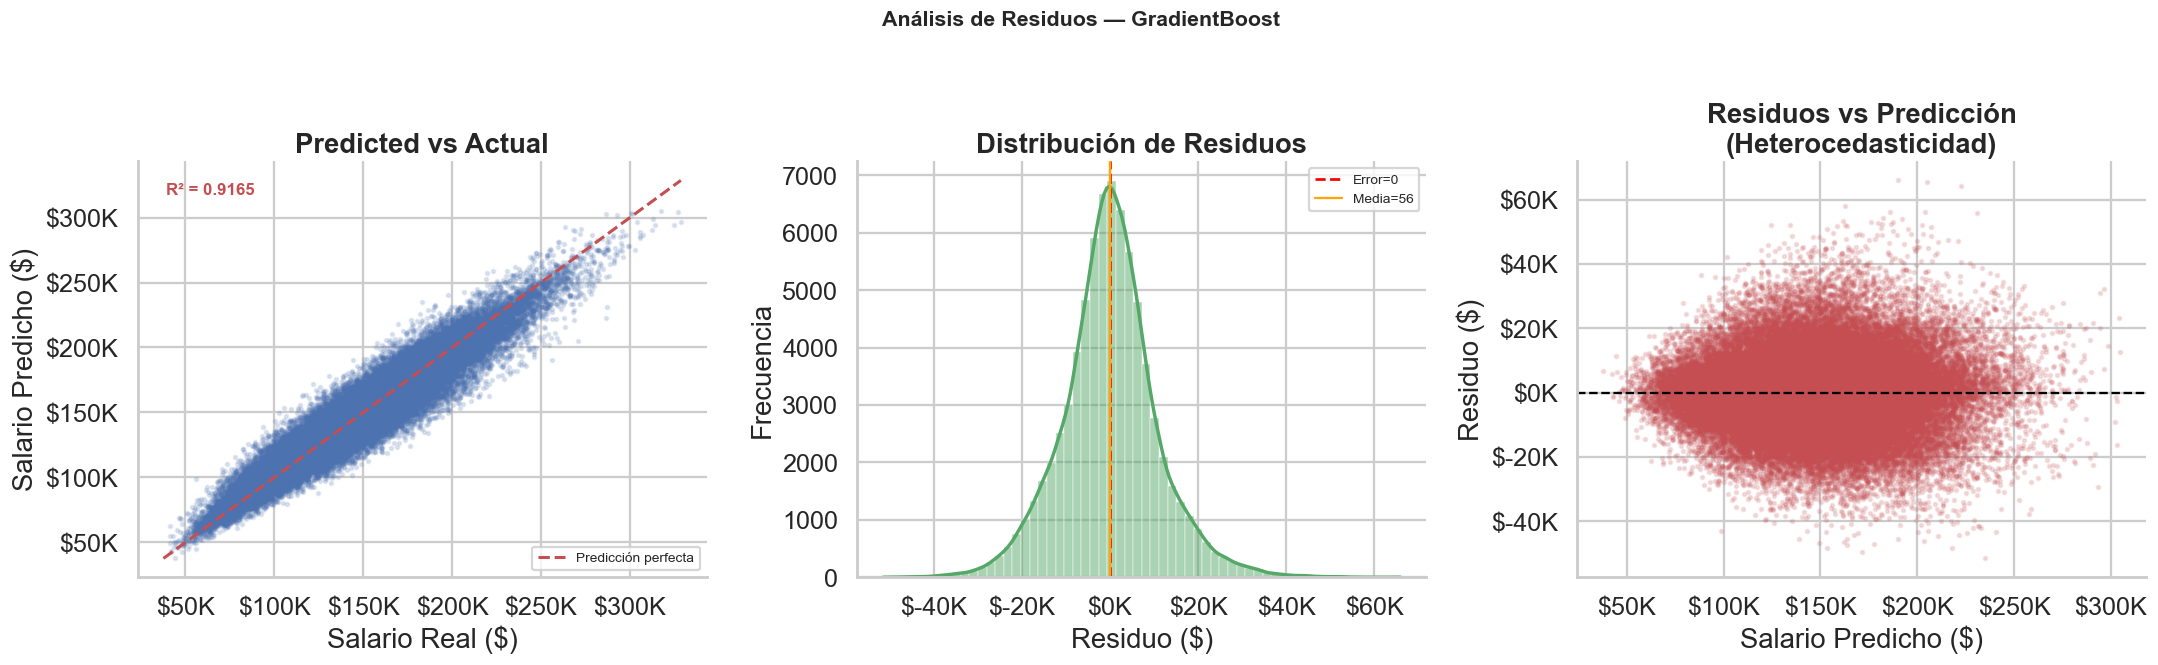


Estadísticos de Residuos — GradientBoost
--------------------------------------------------
  Media de residuos    : $55.75
  Mediana de residuos  : $0.30
  Std de residuos      : $10,813.01
  % obs. con error <10%: 83.2%
  % obs. con error <5% : 55.8%
  Error máx. absoluto  : $65,967.65


In [20]:
# Análisis de residuos (Modelo Ganador)
modelo_ganador_nombre = comparativa_final.iloc[0]['Modelo']
modelo_ganador        = best_models[modelo_ganador_nombre]

y_pred_test  = modelo_ganador.predict(X_test)
residuos     = y_test.values - y_pred_test
residuos_pct = residuos / y_test.values * 100   # error porcentual

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test, alpha=0.15, s=5, color='#4C72B0')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Salario Real ($)')
axes[0].set_ylabel('Salario Predicho ($)')
axes[0].set_title('Predicted vs Actual', fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend(fontsize=9)
r2_val = r2_score(y_test, y_pred_test)
axes[0].text(0.05, 0.92, f'R² = {r2_val:.4f}', transform=axes[0].transAxes,
             fontsize=11, color='#C44E52', fontweight='bold')

# Distribución de residuos
sns.histplot(residuos, bins=60, kde=True, ax=axes[1],
             color='#55A868', edgecolor='white', linewidth=0.3)
axes[1].axvline(0,               color='red',    linestyle='--', linewidth=1.8, label='Error=0')
axes[1].axvline(residuos.mean(), color='orange', linestyle='-',  linewidth=1.5, label=f'Media={residuos.mean():,.0f}')
axes[1].set_xlabel('Residuo ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos', fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend(fontsize=9)

# Residuos vs Predicted (heterocedasticidad)
axes[2].scatter(y_pred_test, residuos, alpha=0.15, s=5, color='#C44E52')
axes[2].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[2].set_xlabel('Salario Predicho ($)')
axes[2].set_ylabel('Residuo ($)')
axes[2].set_title('Residuos vs Predicción\n(Heterocedasticidad)', fontweight='bold')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle(f'Análisis de Residuos — {modelo_ganador_nombre}',
             fontsize=14, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

# Estadísticos resumen de los residuos
print(f'\nEstadísticos de Residuos — {modelo_ganador_nombre}')
print('-' * 50)
print(f'  Media de residuos    : ${residuos.mean():,.2f}')
print(f'  Mediana de residuos  : ${np.median(residuos):,.2f}')
print(f'  Std de residuos      : ${residuos.std():,.2f}')
print(f'  % obs. con error <10%: {(np.abs(residuos_pct) < 10).mean() * 100:.1f}%')
print(f'  % obs. con error <5% : {(np.abs(residuos_pct) < 5).mean() * 100:.1f}%')
print(f'  Error máx. absoluto  : ${np.abs(residuos).max():,.2f}')

**Interpretación del análisis de residuos (GradientBoosting):**

- **Predicted vs Actual (R²=0.9165):** Los puntos se alinean con gran precisión sobre la diagonal perfecta en todo el rango salarial (50K–300K USD), confirmando la robustez del modelo. La dispersión es homogénea y no se observan clusters de error sesgado en ningún tramo, lo que indica que el modelo generaliza correctamente tanto en salarios bajos como altos.

- **Distribución de residuos:** La distribución es prácticamente normal y centrada en 0 (media=55.75 USD, mediana=0.30 USD), lo que confirma que el modelo **NO** tiene sesgo sistemático de predicción. Es decir, no sobreestima ni subestima consistentemente. La desviación estándar de 10,813 USD es coherente con el RMSE reportado. El 83.2% de las observaciones presenta un error inferior al 10% del salario real, y el 55.8% por debajo del 5%, lo que representa una **precisión muy alta** con una amplitud tan grande.

- **Residuos vs Predicción (Heterocedasticidad):** La nube de residuos es razonablemente homogénea en el rango central (100K–200K USD), con una ligera apertura en los extremos, especialmente en salarios predichos altos (>250K USD). Esto es **esperado y aceptable**: el menor volumen de observaciones en la cola superior genera naturalmente mayor incertidumbre en ese tramo, coherente con los 2,336 outliers identificados en el EDA.

### Resumen de las métricas (algoritmos) y sobreajuste

Los resultados de train y test de los modelos revelan patrones distintos que aportan lo siguiente:

**GradientBoosting es el modelo más sólido.** Muestra el mejor rendimiento predictivo (0.916) y, además, el menor sobreajuste de los modelos no lineales (apenas 0.009 de diferencia entre train y test). Esto indica que el modelo ha identificado patrones generales estables que no dependen de memorizar los datos de entrenamiento (overfitting), lo que hace que el modelo sea muy robusto ante futuros datos.

**RandomForest presenta un buen rendimiento pero menor estabilidad.** Aunque logra un resultado de 0.898, muestra un desbalance entre los conjuntos de train y test (sobreajuste de 0.052), lo que indica que su rendimiento se apoya mas o menos en el sobreajuste (overfitting) a los datos conocidos en train, en lugar de generalizar patrones correctamente.

**KNN se queda atrás en rendimiento de forma inconsistente.** Su capacidad predictiva es inferior (0.850) y sigue presentando un sobreajuste de 0.019. 

**ElasticNet presenta mayor robustez, pero bajo rendimiento.** Su sobreajuste es prácticamente nulo (0.0007). Sin embargo, su R2 se topa en 0.793, indicando que el modelo lineal no logra capturar relaciones no lineales complejas del conjunto de datos.

**Conclusión para la selección de modelo.** La decisión de escoger el mejor modelo estara basada en buscar el máximo rendimiento, tratando de encontrar un equilibrio en la interpretabilidad. Es por ello, que escogere el algoritmo GradientBoosting como ganador, no solo rinde de forma notablemente superior en el R2 medio, sino que su estabilidad generalizando frente a RandomForest es claramente superior. Esta elección a pesar de ser un modelo de 'caja negra' a comparación del modelo de ElasticNet que es muy superior en interpretabilidad, extraere los valores SHAP a posteriori, para poder comprender y analizar cuales son las variables mas importantes a la hora de realizar una predicción este algoritmo.


### Decisión final sobre el modelo

Aplicando el principio de maximizar el rendimiento de la predicción asegurando la interpretabilidad y explicabilidad, mi elección es en favor de **GradientBoosting**.

**Justificación:**

Los resultados en test muestran que GradientBoosting es claramente superior en todas las métricas: R2 de 0.916, MAE de 8085 y RMSE de 10813. Ante rendimientos tan superiores entre ElasticNet y este modelo, la ligera desventaja inicial reside en la explicabilidad de la caja negra. Sin embargo, queda compensada por una inmensa ganancia en rendimiento predictivo (más de un 12% de mejora en R2). 

**Rendimiento final del modelo seleccionado en test:**
- R2 Score: 0.916
- MAE: 8085
- RMSE: 10813

Estas métricas confirman que el modelo identifica y modela adecuadamente las interacciones complejas de los salarios, limitando drásticamente el error medio en las estimaciones.


### F. INTERPRETABILIDAD Y EXPLICABILIDAD DEL MODELO (SHAP)

Dado que nuestro principio (decidido anteriormente) nos provoca asegurar la explicabilidad del modelo ganador (Gradient Boosting, el cual es de *caja negra*).
Trataremos lo siguiente:
- Explicabilidad Global: Importancia y dirección del impacto de las variables en todo el modelo.
- Explicabilidad Local: Desglose matemático de predicciones individuales.


In [21]:
# SHAP
modelo_final   = best_models[modelo_ganador_nombre]
preprocesador  = modelo_final.named_steps['preprocesado']
modelo_interno = modelo_final.named_steps['modelo']

X_train_t = preprocesador.transform(X_train)
X_test_t  = preprocesador.transform(X_test)

if hasattr(X_train_t, "toarray"):
    X_train_t = X_train_t.toarray()
    X_test_t  = X_test_t.toarray()

try:
    feature_names = [name.split('__')[-1] for name in preprocesador.get_feature_names_out()]
except AttributeError:
    feature_names = [f'Feature_{i}' for i in range(X_train_t.shape[1])]

X_train_shap = pd.DataFrame(X_train_t, columns=feature_names)
X_test_shap  = pd.DataFrame(X_test_t,  columns=feature_names)

explainer    = shap.TreeExplainer(modelo_interno)
X_sample     = shap.sample(X_train_shap, 1000, random_state=42)
shap_values  = explainer(X_sample)

print(f'Valores SHAP calculados — muestra de {len(X_sample)} observaciones.')
print(f'Valor base (salario promedio del modelo): {explainer.expected_value}')

Valores SHAP calculados — muestra de 1000 observaciones.
Valor base (salario promedio del modelo): [145816.77765747]


Importancia Global de Variables (SHAP Mean |value|) ===



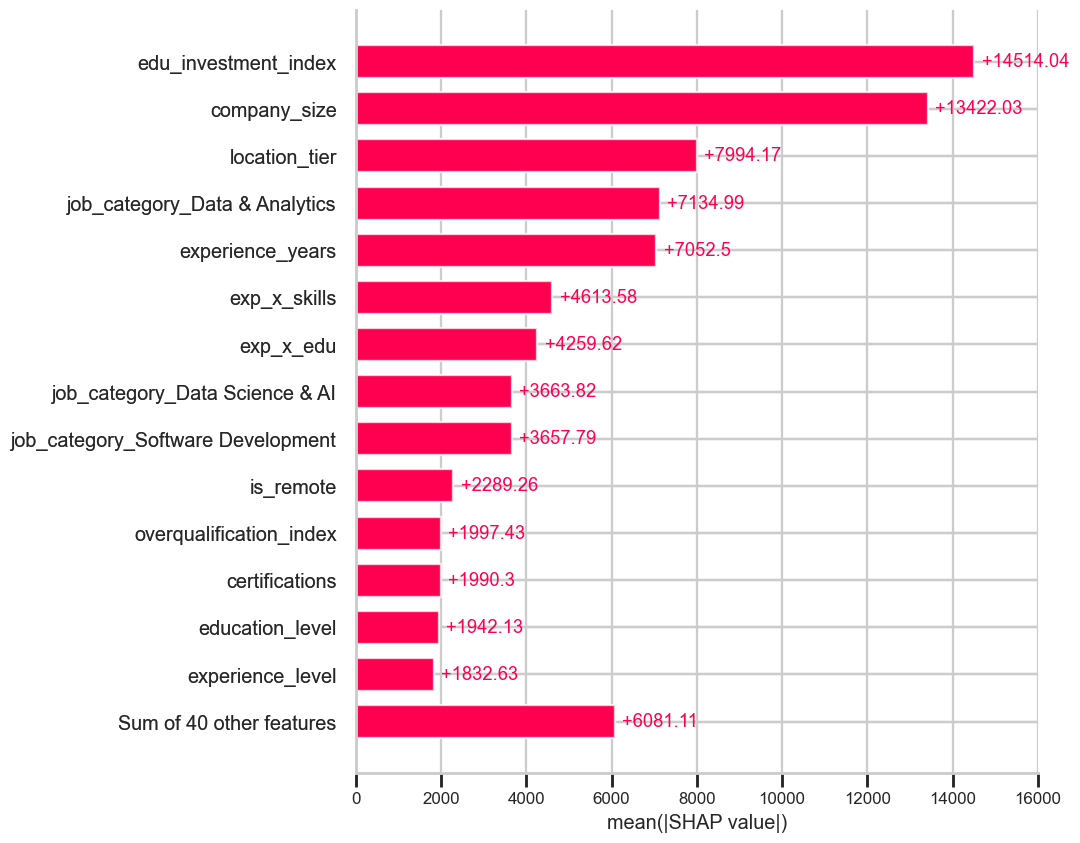

In [22]:
# SHAP Global Bar Plot (Importancia media absoluta)
print('Importancia Global de Variables (SHAP Mean |value|) ===\n')
shap.plots.bar(shap_values, max_display=15)

#### Interpretación Bar Plot (Importancia Global Media |SHAP|)

El ranking de importancia global revela que las **dos variables más determinantes del salario son variables creadas en la sección Feature Engineering**:

1. **`edu_investment_index` (+14,514 USD):** El índice que combina nivel educativo con el costo-país de formación es, con diferencia, el mayor motor salarial del modelo. Esto captura una realidad de mercado: un PhD en USA no tiene el mismo valor de mercado que un PhD en India, y el modelo lo cuantifica.

2. **`company_size` (+13,422 USD):** El tamaño de empresa es el segundo factor más determinante. Trabajar en una empresa Enterprise o Large supone de media más de 13K USD de impacto absoluto en el salario predicho respecto a la base.

3. **`location_tier` (+7,994 USD):** La jerarquía geográfica tiene un impacto de casi 8K USD, reflejando la prima salarial estructural de mercados mas valorados (USA, UK, Australia) frente a mercados emergentes.

4. **`experience_years` (+7,052 USD):** La experiencia real, en su forma original, ocupa el quinto lugar, por detrás de dos variables de FE basadas en ella (`edu_investment_index`, `exp_x_skills`, `exp_x_edu`), lo que confirma que las interacciones creadas capturan dimensiones adicionales no recogidas por la variable cruda.

5. **Features de categoría de rol** (`job_category_Data & Analytics` +7,135 USD, `Data Science & AI` +3,664 USD, `Software Development` +3,658 USD): La agrupación de roles confirma que pertenecer a la categoría de Data & Analytics tiene la suma más alta, seguida de Data Science & AI.

La suma de las 40 variables restantes contribuye +6,081 USD, indicando que el modelo distribuye correctamente la señal entre las variables del FE principales y el resto del espacio de variables.

#### Explicabilidad Global (Summary Plot)

El gráfico resumen (beeswarm) nos permite entender de un vistazo el núcleo del modelo. 
*   **Eje Y:** Muestra las variables ordenadas por importancia (la de arriba es la que más impacta en el salario).
*   **Eje X:** Muestra el impacto en la predicción (hacia la derecha aumenta el salario, hacia la izquierda lo disminuye).
*   **Color:** Representa el valor original de la variable (rojo = valor alto, azul = valor bajo).


Dirección del Impacto por Variable (Beeswarm)



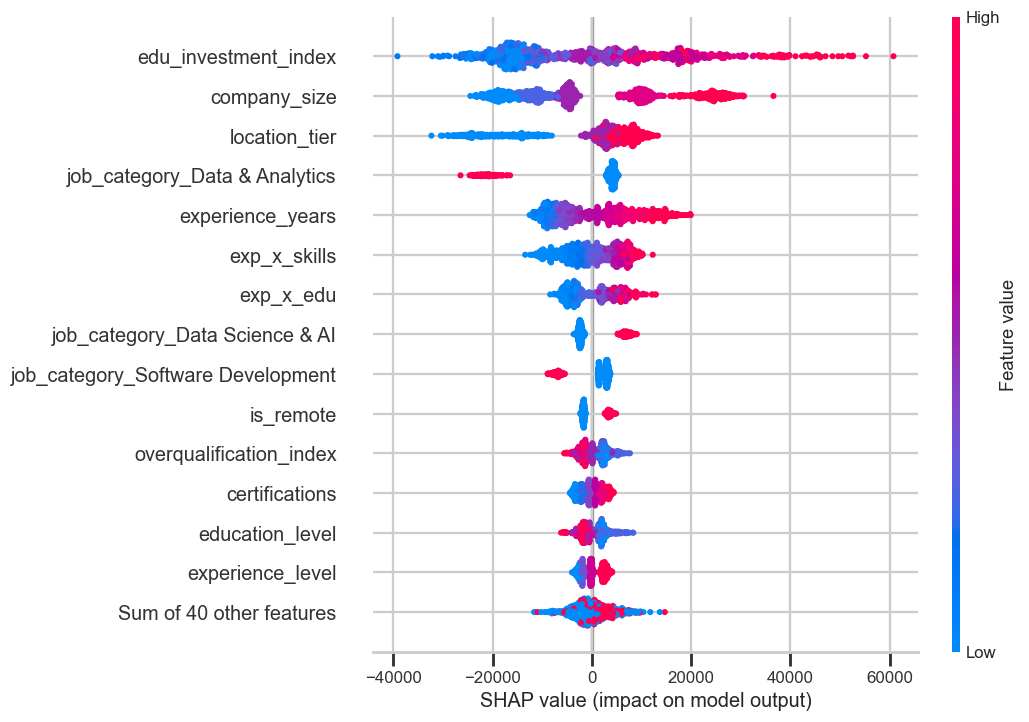

In [23]:
# Genero el gráfico resumen de impacto global
print('Dirección del Impacto por Variable (Beeswarm)\n')
shap.plots.beeswarm(shap_values, max_display=15)

#### Interpretación Beeswarm (Dirección del Impacto)

El beeswarm añade la dimensión direccional a la importancia:

- **`edu_investment_index`:** Los puntos rojos (valores altos del índice, alta educación en países con alto costo de formación) se extienden hacia la derecha llegando hasta +60K USD de impacto positivo. Los puntos azules (educación baja en países de bajo costo) empujan hasta -40K USD. Es la variable con el rango de impacto más amplio de todo el modelo.

- **`company_size`:** Existe un patrón claro, los valores altos (Enterprise/Large, puntos rojos) generan un impacto positivo concentrado, mientras que los valores bajos (Startup/Small, puntos azules) tienen un impacto negativo. La separación limpia entre ambos grupos confirma que el tamaño de empresa opera como un escalón salarial estructural.

- **`location_tier`:** Comportamiento bifurcado: tier 2 (USA/UK, rojo) suma hasta +20K USD, tier 0 (India/Remote, azul) resta hasta -20K USD. El impacto es simétrico y consistente, sin casos atípicos.

- **`job_category_Data & Analytics`:** Los puntos rojos (pertenece a la categoría) tienen un impacto negativo concentrado en torno a -20K USD. Esto indica que, controlando el resto de variables, este grupo salarial tiene una prima negativa respecto a la categoría base de referencia del OHE, no significa que ganen menos en términos absolutos, sino menos que la categoría omitida en el encoding.

- **`experience_years`:** Progresión limpia de azul (poca experiencia, impacto negativo) a rojo (mucha experiencia, impacto positivo hasta +20K USD). La relación es monótona y positiva, sin umbrales abruptos.

- **`is_remote`:** Impacto positivo concentrado y moderado (+2,289 USD media), con poca dispersión — el teletrabajo suma de forma consistente y sin grandes outliers.

Dependence Plot — edu_investment_index (variable más importante)



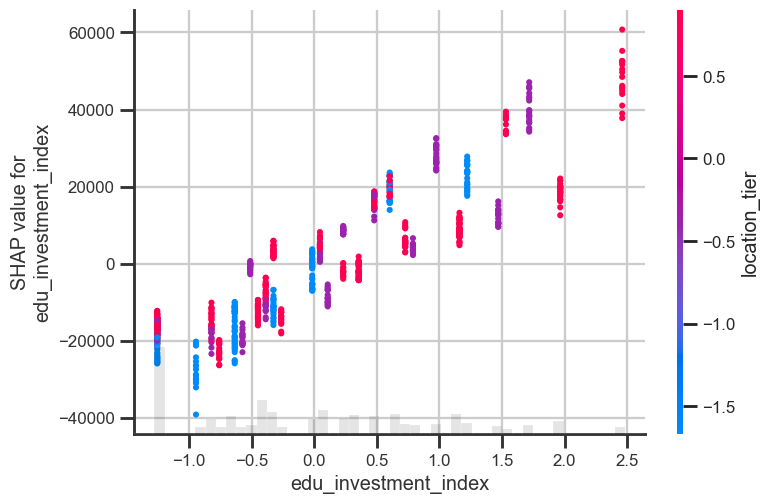

In [24]:
# SHAP Global 3 Dependence Plot Relación no lineal de la top feature
top_feature = shap_values.abs.mean(0).values.argmax()
top_name    = feature_names[top_feature]

print(f'Dependence Plot — {top_name} (variable más importante)\n')
shap.plots.scatter(shap_values[:, top_name], color=shap_values)

#### Interpretación Dependence Plot (`edu_investment_index` × `location_tier`)

El gráfico de dependencia de la variable más importante revela su estructura no lineal y la interacción con `location_tier` (coloreado):

- **Relación monotónica positiva:** A medida que `edu_investment_index` aumenta (mayor nivel educativo en países de mayor costo), el impacto SHAP crece de forma consistente desde -40K USD hasta +60K USD. La relación no es perfectamente lineal sino escalonada, lo que justifica el uso de un modelo de árboles frente a un modelo lineal.

- **Interacción con `location_tier`:** El color del punto (azul=location_tier bajo, rojo=location_tier alto) muestra que, para el mismo valor del índice, los individuos en países tier-2 (rojo) reciben un empuje SHAP ligeramente superior. Esto refleja que el modelo detecta una **doble prima geográfica**: tanto por el índice en sí como por la ubicación directa, capturando matices que ninguna de las dos variables por separado podría recoger.

- **Columna de valores bajos (índice ≈ -1.5 a -1.0):** La dispersión vertical en este tramo es alta individuos con educación baja en países de bajo costo tienen impactos SHAP muy variables (-40K USD a -10K USD), sugiriendo que otras variables del modelo (rol, tamaño de empresa) modulan significativamente el salario en este segmento, donde el índice tiene menor poder discriminante.

- **Implicación de negocio:** Invertir en educación formal tiene el mayor retorno salarial cuando se combina con trabajar en un mercado de alto costo de vida. Un Master en USA (índice ≈ 2.0) supone un impacto SHAP de +40K–60K USD, mientras que el mismo nivel educativo desde India (índice ≈ 0.5) genera un impacto de +10K–25K USD.

#### Explicabilidad Local (Waterfall Plot)

A continuación, analizamos una predicción individual. Esto es fundamental, ya que permite explicar exactamente por qué a un empleado concreto se le ha predicho un salario específico, mostrando cuánto suma o resta cada una de sus características desde el salario base promedio.



------------------------------------------------------------
Perfil: Junior (menor experiencia)
  Salario base (promedio global): $145,816.78
  Salario predicho              : $83,093.26
------------------------------------------------------------


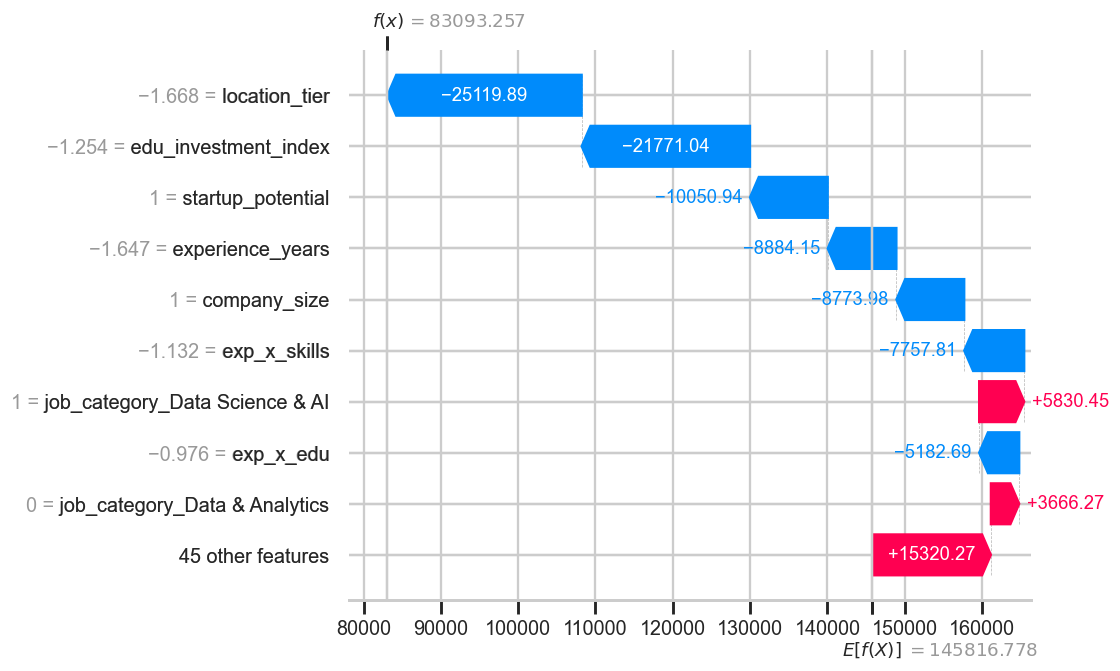


------------------------------------------------------------
Perfil: Senior (experiencia media)
  Salario base (promedio global): $145,816.78
  Salario predicho              : $77,414.40
------------------------------------------------------------


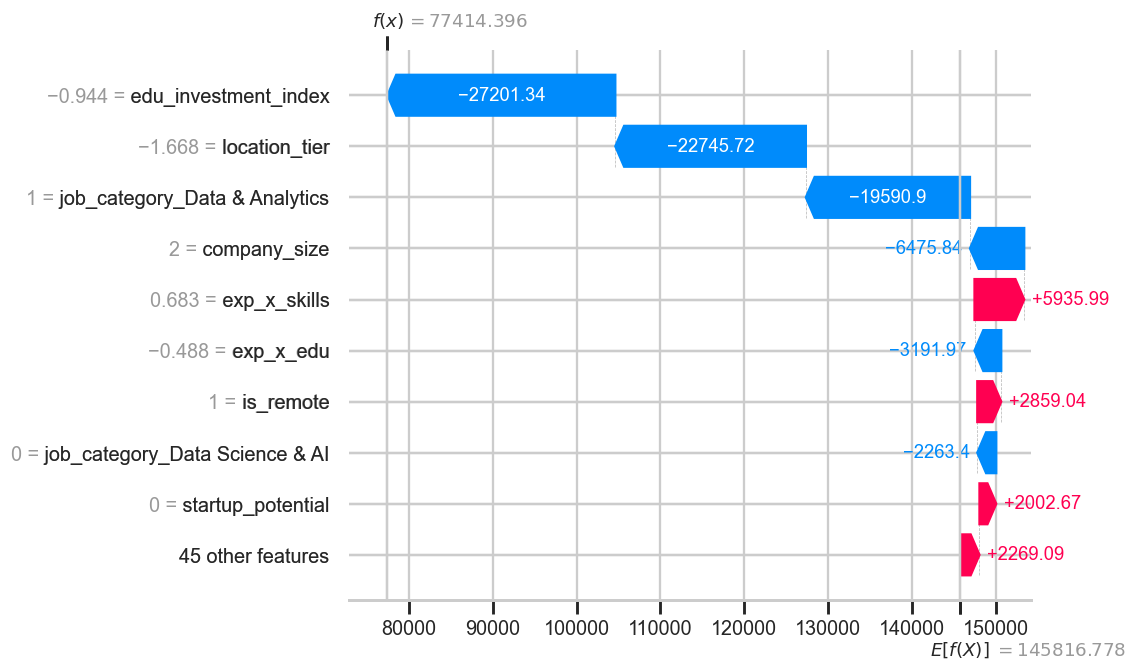


------------------------------------------------------------
Perfil: Expert (mayor experiencia)
  Salario base (promedio global): $145,816.78
  Salario predicho              : $226,580.76
------------------------------------------------------------


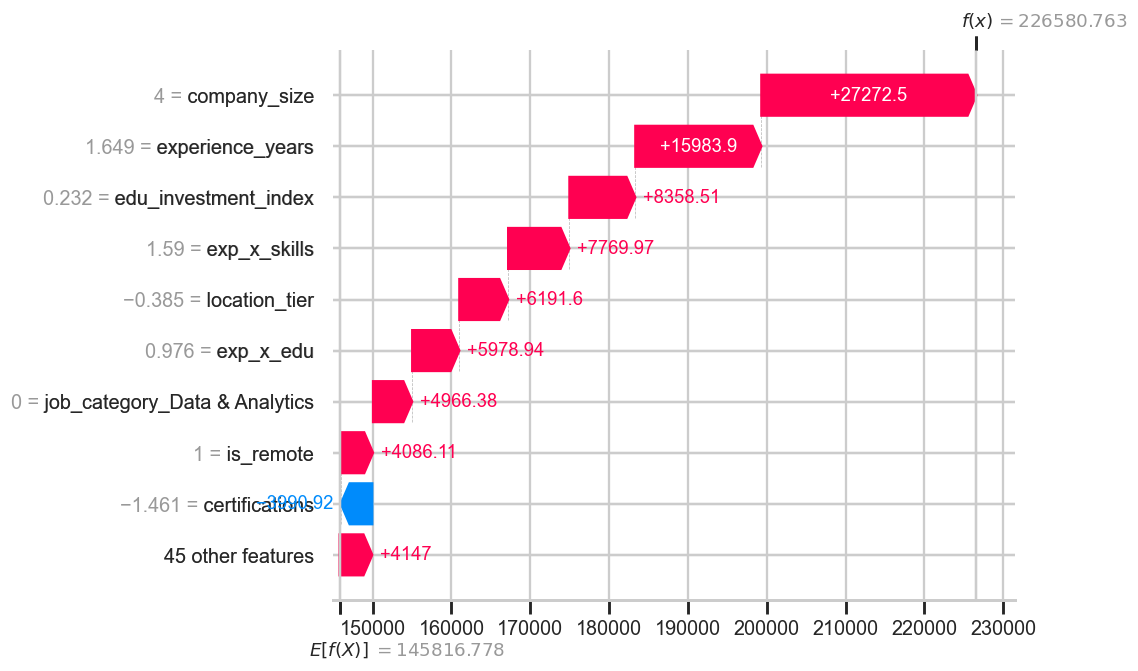

In [25]:
# SHAP Local Waterfall — 3 perfiles 

# Definimos 3 perfiles representativos del test set
idx_junior = X_test_shap['experience_years'].nsmallest(1).index[0]

med_exp = X_test_shap['experience_years'].median()
idx_senior = (X_test_shap['experience_years'] - med_exp).abs().idxmin()

idx_expert = X_test_shap['experience_years'].nlargest(1).index[0]

perfiles = {
    'Junior (menor experiencia)' : idx_junior,
    'Senior (experiencia media)' : idx_senior,
    'Expert (mayor experiencia)' : idx_expert
}

# Fix: extraer escalar del expected_value (puede ser array en algunas versiones de SHAP)
valor_base = float(np.array(explainer.expected_value).flatten()[0])

for nombre, idx in perfiles.items():
    shap_local = explainer(X_test_shap.iloc[[idx]])
    prediccion = modelo_interno.predict(X_test_shap.iloc[[idx]].values)[0]
    real       = y_test.iloc[y_test.index.get_loc(idx)] if idx in y_test.index else 'N/A'
    
    print(f'\n{"-"*60}')
    print(f'Perfil: {nombre}')
    print(f'  Salario base (promedio global): ${valor_base:,.2f}')
    print(f'  Salario predicho              : ${prediccion:,.2f}')
    if isinstance(real, (int, float)):
        print(f'  Salario real                  : ${real:,.2f}')
    print(f'{"-"*60}')
    shap.plots.waterfall(shap_local[0], max_display=10)

#### Interpretación Waterfall Local: 3 Perfiles Contrastados

El salario base del modelo (promedio global de la base de datos) es **145,816.78 USD**. A partir de ahí, cada característica individual suma o resta dólares hasta llegar a la predicción final de cada perfil.

---

**Perfil Junior — Predicción: 83,093 USD (-62,724 USD respecto a la base)**

Este perfil representa al individuo con menor experiencia del conjunto test. El modelo lo penaliza fuertemente a través de un efecto combinado y coherente:

- `location_tier = -1.668` resta **-25,120 USD**: trabaja desde una ubicación de nivel salarial bajo, el mayor driver negativo individual.
- `edu_investment_index = -1.254` resta **-21,771 USD**: educación baja en un país de bajo costo de formación, lo que el modelo interpreta como bajo capital humano contextualizado.
- `startup_potential = 1` resta **-10,051 USD**: trabaja en una startup o empresa pequeña en un hub tecnológico, entorno asociado a salarios más bajos en etapas tempranas.
- `experience_years = -1.647` resta **-8,884 USD**: muy poca experiencia real, penalización directa.
- `company_size = 1` (Small) resta **-8,774 USD**: refuerza el efecto de empresa pequeña.

El único contrapeso positivo relevante es pertenecer a `job_category_Data Science & AI` (+5,830 USD), que amortigua parcialmente las penalizaciones estructurales. Las 45 variables restantes suman colectivamente +15,320 USD, pero no son suficientes para compensar los cinco factores negativos dominantes.

---

**Perfil Senior — Predicción: 77,414 USD (-68,403 USD respecto a la base)**

Este perfil, a pesar de tener experiencia media, es el que recibe la predicción más baja de los tres. El modelo identifica una combinación especialmente penalizante:

- `edu_investment_index = -0.944` resta **-27,201 USD**: el mayor impacto negativo, incluso superior al del perfil Junior en términos absolutos. Educación media en un contexto geográfico de bajo retorno.
- `location_tier = -1.668` resta **-22,746 USD**: mismo nivel geográfico bajo que el Junior.
- `job_category_Data & Analytics = 1` resta **19,591 USD**: pertenecer a esta categoría genera un impacto negativo de casi $20K respecto a la categoría base de referencia, es la penalización más llamativa y contraintuitiva a primera vista, explicable porque en esta base de datos el OHE toma como referencia una categoría con mayor prima salarial estructural.
- `company_size = 2` (Medium) resta **-6,476 USD**: tamaño de empresa intermedio, sin la prima de las grandes corporaciones.

Los factores positivos son modestos: `exp_x_skills` (+5,936 USD), `is_remote = 1` (+2,859 USD) y `startup_potential` (+2,003 USD) no compensan el peso de los tres drivers negativos principales. Este perfil ilustra cómo la combinación de ubicación baja + educación no contextualizada + categoría de rol puede deprimir el salario predicho incluso con experiencia razonable.

---

**Perfil Expert — Predicción: 226,581 USD (+80,764 USD respecto a la base)**

Este perfil es el caso opuesto: prácticamente todas las variables empujan en la misma dirección positiva, generando el efecto acumulativo más potente del análisis.

- `company_size = 4` (Enterprise) suma **+27,273 USD**: el mayor impacto positivo individual de los tres perfiles. Trabajar en una empresa Enterprise es el factor con mayor poder de elevación salarial en este modelo.
- `experience_years = 1.649` suma **+15,984 USD**: máxima experiencia, segundo driver más potente.
- `edu_investment_index = 0.232` suma **+8,359 USD**: aunque el índice no es extremadamente alto, contribuye positivamente.
- `exp_x_skills = 1.59` suma **+7,770 USD**: la interacción entre alta experiencia y alto número de habilidades genera una prima adicional que ninguna de las dos variables capturaría por separado.
- `location_tier = -0.385` suma **+6,192 USD**: nivel geográfico medio-alto.
- `exp_x_edu` (+5,979 USD), `is_remote` (+4,086 USD) y la categoría de rol (+4,966 USD) refuerzan la predicción.

La única penalización es `certifications = -1.461` (-3,001 USD), un valor bajo de certificaciones que el modelo penaliza ligeramente. Las 45 variables restantes suman +4,147 USD, aportando de forma consistente.

---

**Conclusión del análisis local:** Los tres waterfall plots demuestran que el modelo no es una 'caja negra', cada predicción es completamente auditable. La diferencia de **149,167 USD** entre el perfil Junior (83K USD) y el Expert (227K USD) queda matemáticamente explicada variable por variable. Los factores con mayor poder de palanca son `company_size`, `edu_investment_index` y `location_tier`, los cuales aparecen como deterministas dominantes en los tres perfiles de forma consistente con el análisis global de SHAP.

### Interpretación de los Resultados de SHAP

**Análisis Global Bar Plot (Importancia Media |SHAP|):**
El ranking de importancia global revela que las dos variables más determinantes del salario son features de nueva creación: `edu_investment_index` (+14,514 USD de impacto medio absoluto) y `company_size` (+13,422 USD), muy por encima del resto. Le siguen `location_tier` (+7,994 USD) y `experience_years` (+7,052 USD) que a pesar de ser la variable original más potente, queda por detrás de dos features engineered basadas en ella, validando el proceso de FE. Las categorías de rol (`Data & Analytics`, `Data Science & AI`, `Software Development`) también aparecen como drivers relevantes, confirmando que el área funcional tiene un impacto salarial estructural independiente del resto de factores.

**Análisis Global Beeswarm (Dirección del Impacto):**
El beeswarm añade la dimensión direccional: `edu_investment_index` presenta el rango de impacto más amplio de todo el modelo (de -40K USD a +60K USD), con una progresión clara de azul a rojo que confirma su relación monótona positiva. `company_size` opera como un escalón discreto y limpio, Enterprise/Large suman, Startup/Small restan, sin casos atípicos. `experience_years` muestra una progresión igualmente monótona hasta +20K USD. `is_remote` contribuye de forma consistente y moderada (+2,289 USD medio), sin dispersión extrema.

**Análisis Global Dependence Plot (`edu_investment_index`):**
La variable más importante no actúa de forma lineal sino escalonada, justificando el uso de árboles frente a modelos lineales. La interacción con `location_tier` (color del punto) revela una doble prima geográfica: para el mismo valor del índice, individuos en países tier-2 reciben un empuje SHAP adicional. El impacto va desde -40K USD (educación baja en país de bajo costo) hasta +60K USD (educación alta en mercado anglosajón), con una diferencia de hasta 100K USD imputable exclusivamente a esta variable.

**Análisis Local Waterfall (3 Perfiles Contrastados):**
Partiendo del salario base global de **$145,817**, los tres perfiles ilustran cómo el modelo descompone matemáticamente cada predicción. El perfil **Junior** (83,093 USD, -62,724 USD) es penalizado principalmente por `location_tier` (-25,120 USD) y `edu_investment_index` (-21,771 USD) geografía y educación contextualizada son sus dos lastres dominantes. El perfil **Senior** (77,414 USD, -68,403 USD) recibe la predicción más baja a pesar de tener experiencia media, debido a la combinación más penalizante del análisis: `edu_investment_index` (-27,201 USD), `location_tier` (-22,746 USD) y `job_category_Data & Analytics` (-19,591 USD) actuando simultáneamente. El perfil **Expert** (226,581 USD, +80,764 USD) acumula prácticamente todos los factores en positivo, liderado por `company_size` Enterprise (+27,273 USD) y máxima experiencia (+15,984 USD). La diferencia de **$149,167** entre el perfil más bajo y el más alto queda auditada variable por variable, demostrando la explicabilidad total del modelo.

**Conclusión:** El análisis SHAP confirma que los tres ejes fundamentales que determinan el salario en este mercado son el **contexto educativo-geográfico** (`edu_investment_index`), el **tamaño y tipo de empresa** (`company_size`) y la **ubicación geográfica** (`location_tier`). La experiencia, aunque relevante, amplifica su efecto a través de las interacciones creadas (`exp_x_skills`, `exp_x_edu`) más que por sí sola. Un individuo que optimice simultáneamente estos tres ejes: alta formación en mercado de alto costo, empresa Enterprise y ubicación tier-2; puede esperar un salario predicho superior en más de 100K USD respecto a la media global.

### G. VISUALIZACIÓN DE INSIGHTS CLAVE
Trataremos los siguientes aspectos:
- Cruce salarial por tamaño de empresa y nivel geográfico
- Distribución salarial por área funcional
- Ranking de variables por impacto en el modelo (SHAP)
- Evolución del impacto SHAP a lo largo de los segmentos de carrera

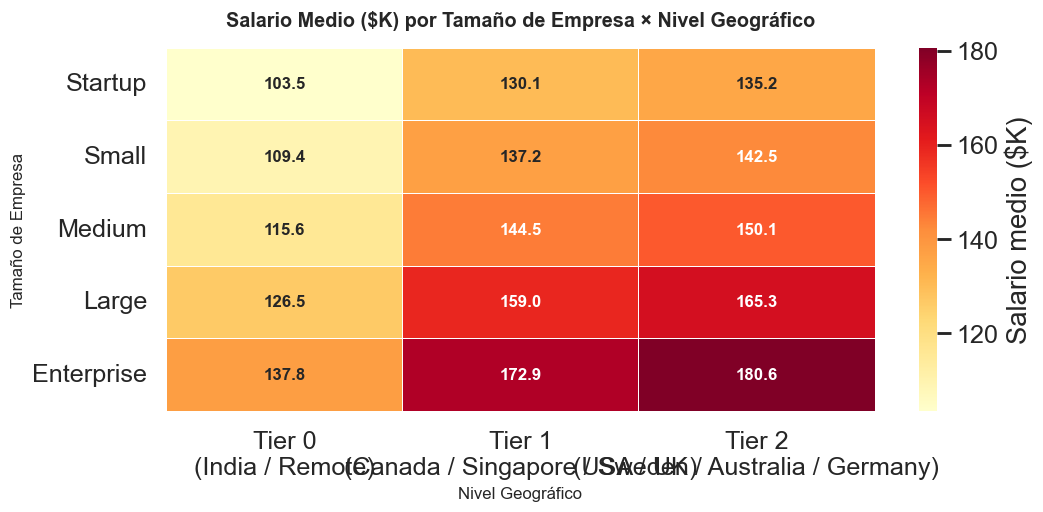

In [26]:
# Salario medio por Location Tier × Company Size
orden_size = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']
etiquetas_tier = {0: 'Tier 0\n(India / Remote)', 1: 'Tier 1\n(Canada / Singapore / Sweden)', 2: 'Tier 2\n(USA / UK / Australia / Germany)'}

df_heat = (df.groupby(['company_size', 'location'])['salary']
             .mean()
             .reset_index())
df_heat['location_tier'] = df_heat['location'].map({
    'USA': 2, 'UK': 2, 'Australia': 2, 'Germany': 2, 'Netherlands': 2,
    'Canada': 1, 'Sweden': 1, 'Singapore': 1, 'India': 0, 'Remote': 0
})
df_heat['tier_label'] = df_heat['location_tier'].map(etiquetas_tier)
df_pivot = (df_heat.groupby(['company_size', 'tier_label'])['salary']
                   .mean()
                   .unstack()
                   .reindex(orden_size))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_pivot / 1000, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Salario medio ($K)'},
            ax=ax, annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Salario Medio ($K) por Tamaño de Empresa × Nivel Geográfico',
             fontweight='bold', fontsize=13, pad=14)
ax.set_xlabel('Nivel Geográfico', fontsize=11)
ax.set_ylabel('Tamaño de Empresa', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

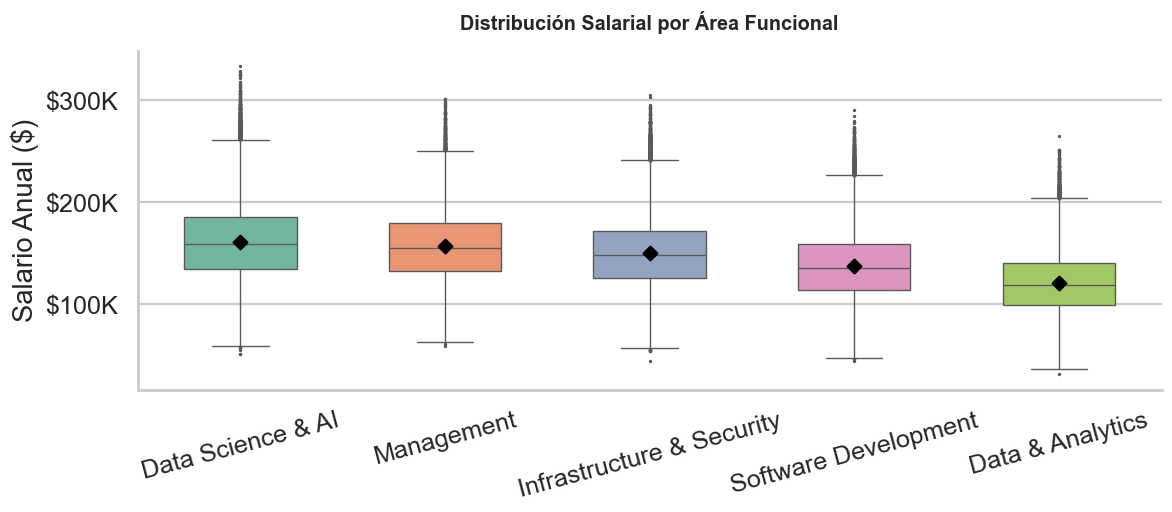

In [27]:
# Distribución salarial por Job Category
orden_cat = (df_fe.groupby('job_category')['salary']
                  .median()
                  .sort_values(ascending=False)
                  .index)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_fe, x='job_category', y='salary',
            order=orden_cat, palette='Set2',
            width=0.55, fliersize=1.2, linewidth=0.9, ax=ax)

medias = df_fe.groupby('job_category')['salary'].mean()
for i, cat in enumerate(orden_cat):
    ax.scatter(i, medias[cat], color='black', zorder=5, s=40, marker='D')

ax.set_title('Distribución Salarial por Área Funcional',
             fontweight='bold', fontsize=13, pad=14)
ax.set_xlabel('')
ax.set_ylabel('Salario Anual ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=15)
sns.despine()
plt.tight_layout()
plt.show()

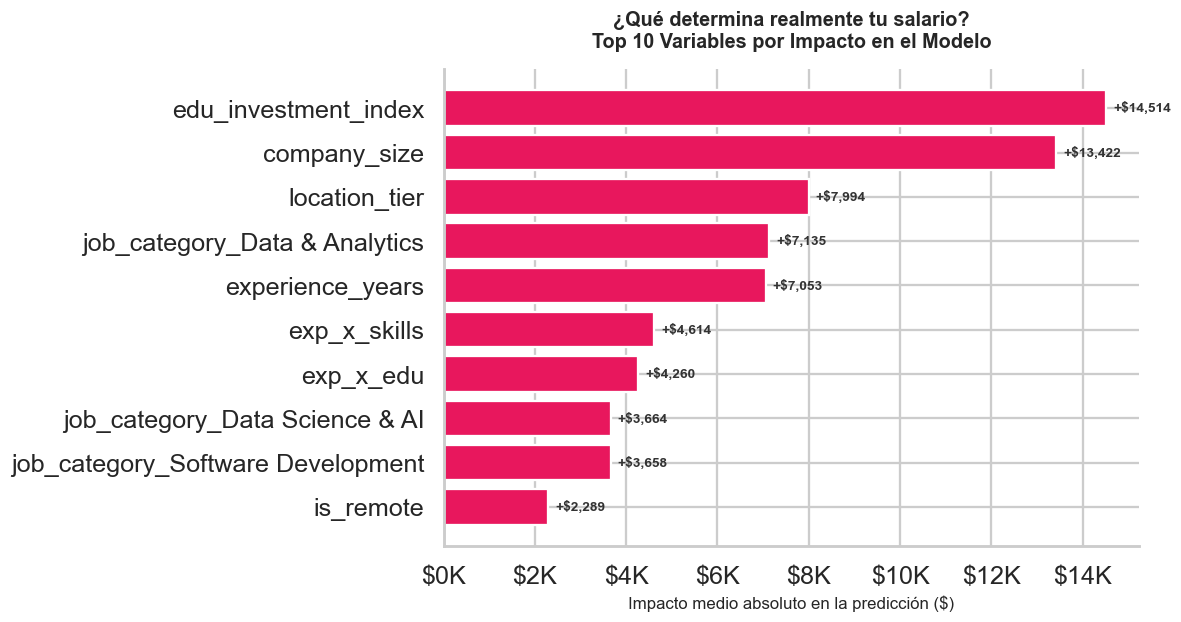

In [28]:
# Top 10 variables SHAP
shap_imp = pd.DataFrame({
    'Feature' : feature_names,
    'SHAP_mean': np.abs(shap_values.values).mean(axis=0)
}).sort_values('SHAP_mean', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(shap_imp['Feature'][::-1], shap_imp['SHAP_mean'][::-1],
               color='#E8175D', edgecolor='white')

for bar, val in zip(bars, shap_imp['SHAP_mean'][::-1]):
    ax.text(val + 150, bar.get_y() + bar.get_height() / 2,
            f'+${val:,.0f}', va='center', fontsize=9, fontweight='bold', color='#333333')

ax.set_xlabel('Impacto medio absoluto en la predicción ($)', fontsize=11)
ax.set_title('¿Qué determina realmente tu salario?\nTop 10 Variables por Impacto en el Modelo',
             fontweight='bold', fontsize=13, pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
sns.despine()
plt.tight_layout()
plt.show()

### Interpretación de los Insights Clave

**Salario Medio por Tamaño de Empresa × Nivel Geográfico:**
El heatmap confirma empíricamente las dos variables drivers estructurales identificados por SHAP. La combinación Enterprise + Tier 2 (USA/UK/Australia/Germany) alcanza el salario medio más alto de la base de datos con **180.6K USD**, mientras que el extremo opuesto Startup + Tier 0 (India/Remote) se sitúa en **103.5K USD**, una brecha de **77.1K USD anuales** explicable únicamente por dos variables de perfil. Cada aumento de escalón de tamaño de empresa suma entre 6K y 15K USD, y cada escalón geográfico entre 25K y 35K USD, independientemente del punto de partida. Esto tiene una implicación directa: para un profesional en Tier 0, el salto de Startup a Enterprise (+34.3K USD) es comparable en impacto al salto geográfico de Tier 0 a Tier 2 permaneciendo en Startup (+31.7K USD) — ambas palancas tienen un poder de transformación salarial similar y son accionables de forma independiente.

**Distribución Salarial por Área Funcional:**
Data Science & AI lidera el ranking con la mediana más alta y la mayor amplitud intercuartílica, reflejando tanto la prima salarial del sector como su alta dispersión interna. Es decir, un junior de Data Science puede ganar menos que un senior de Management, pero el techo del área es el más alto del mercado. Management ocupa el segundo lugar con una distribución compacta, indicando mayor homogeneidad salarial dentro del rol. Infrastructure & Security y Software Development presentan distribuciones similares en rango pero con medias distintas (150K USD vs 135K USD aproximadamente). Data & Analytics es el área con la mediana más baja y la distribución más estrecha, coherente con el impacto SHAP negativo de `job_category_Data & Analytics` identificado en la sección F.

**Top 10 Variables por Impacto en el Modelo:**
El gráfico proporciona la respuesta al objetivo central del proyecto de forma directa y cuantificada. `edu_investment_index` (+14,514 USD) y `company_size` (+13,422 USD) dominan el ranking con una ventaja de casi el doble sobre el tercer factor, `location_tier` (+7,994 USD). Significativamente, `experience_years` es la variable que cualquier individuo tomaría como la más importante, pero sin embargo aparece en quinta posición (+7,053 USD), empatada prácticamente con `job_category_Data & Analytics` (+7,135 USD) y por detrás de dos variables construidas en el FE a partir de ella (`exp_x_skills` +4,614 USD, `exp_x_edu` +4,260 USD). El trabajo remoto (`is_remote`, +2,289 USD) cierra el top 10 como la variable de menor impacto individual pero con una característica diferencial: es el único completamente controlable por el profesional de forma inmediata, sin requerir cambio de empresa, país ni formación adicional.

### H. SIMULADOR DE SALARIO 
Trataremos los siguientes aspectos:
- Encapsulación del pipeline completo en una función de inferencia
- Aplicación automática del Feature Engineering sobre inputs crudos
- Predicción del salario de mercado esperado
- Desglose de los 5 factores que más suman y más restan al salario predicho
- Posicionamiento del candidato en el percentil del dataset


In [29]:
# Configuración funciones para seccion H-I

# Pipeline
modelo_ganador_nombre = comparativa_final.iloc[0]['Modelo']
modelo_ganador        = best_models[modelo_ganador_nombre]
preprocesador         = modelo_ganador.named_steps['preprocesado']
modelo_interno        = modelo_ganador.named_steps['modelo']

# Feature names
try:
    feature_names = [n.split('__')[-1] for n in preprocesador.get_feature_names_out()]
except AttributeError:
    feature_names = [f'Feature_{i}' for i in range(preprocesador.transform(X_train[:1]).shape[1])]

# SHAP
X_train_t    = preprocesador.transform(X_train)
X_train_t    = X_train_t.toarray() if hasattr(X_train_t, 'toarray') else X_train_t
X_train_shap = pd.DataFrame(X_train_t, columns=feature_names)
explainer    = shap.TreeExplainer(modelo_interno)
valor_base   = float(np.array(explainer.expected_value).flatten()[0])

# Feature Engineering
def aplicar_feature_engineering(df_input):
    df = df_input.copy()

    df['experience_level']  = pd.cut(df['experience_years'], bins=[-1,3,7,13,20],
                                     labels=['junior','mid','senior','expert'])
    df['total_credentials'] = df['skills_count'] + df['certifications']
    df['skills_per_year']   = df['skills_count'] / (df['experience_years'] + 1)

    edu_dtype  = pd.CategoricalDtype(['High School','Diploma','Bachelor','Master','PhD'], ordered=True)
    size_dtype = pd.CategoricalDtype(['Startup','Small','Medium','Large','Enterprise'], ordered=True)
    df['edu_level_ord']    = df['education_level'].astype(edu_dtype).cat.codes
    df['company_size_ord'] = df['company_size'].astype(size_dtype).cat.codes

    df['high_demand_role']     = df['job_title'].isin({'AI Engineer','Machine Learning Engineer',
                                                        'Data Scientist','Cloud Engineer'}).astype(int)
    df['is_remote']            = (df['remote_work'] == 'Yes').astype(int)
    df['high_salary_industry'] = df['industry'].isin({'Finance','Technology','Consulting'}).astype(int)

    df['exp_x_skills'] = df['experience_years'] * df['skills_count']
    df['exp_x_edu']    = df['experience_years'] * df['edu_level_ord']

    df['location_tier'] = df['location'].map({
        'USA':2,'UK':2,'Australia':2,'Germany':2,'Netherlands':2,
        'Canada':1,'Sweden':1,'Singapore':1,'India':0,'Remote':0
    }).fillna(0)

    df['edu_investment_index'] = df['edu_level_ord'] * df['location'].map({
        'USA':1.5,'UK':1.3,'Australia':1.3,'Canada':1.2,'Germany':0.7,
        'Netherlands':0.8,'Sweden':0.7,'India':0.5,'Singapore':1.1
    }).fillna(1.0)

    df['overqualification_index'] = 0.0
    df['geo_leverage']    = ((df['is_remote']==1) & (df['high_demand_role']==1) &
                              (df['location_tier']<2)).astype(int)
    df['career_efficiency'] = df['total_credentials'] / (df['edu_level_ord'] + 1)
    df['remote_industry']   = df['remote_work'] + '_' + df['industry']
    df['startup_potential'] = (df['location'].isin(['USA','UK','Singapore','India','Netherlands']) &
                                df['company_size'].isin(['Startup','Small'])).astype(int)

    df['job_category'] = df['job_title'].map({
        'AI Engineer':'Data Science & AI', 'Machine Learning Engineer':'Data Science & AI',
        'Data Scientist':'Data Science & AI', 'Data Analyst':'Data & Analytics',
        'Business Analyst':'Data & Analytics', 'Frontend Developer':'Software Development',
        'Backend Developer':'Software Development', 'Software Engineer':'Software Development',
        'DevOps Engineer':'Infrastructure & Security', 'Cloud Engineer':'Infrastructure & Security',
        'Cybersecurity Analyst':'Infrastructure & Security', 'Product Manager':'Management'
    })

    return df.drop(columns=[c for c in ['job_title','location','industry','remote_work',
                                         'company_size_ord','edu_level_ord'] if c in df.columns])

print(f'✅ Setup completado — Modelo: {modelo_ganador_nombre} | '
      f'Base SHAP: ${valor_base:,.2f} | Features: {len(feature_names)}')

✅ Setup completado — Modelo: GradientBoost | Base SHAP: $145,816.78 | Features: 54


In [37]:
# Diccionario de traducción — variable técnica → lenguaje natural
TRADUCCIONES = {
    'edu_investment_index'                   : 'Nivel educativo en país de alto coste',
    'company_size'                           : 'Tamaño de empresa',
    'location_tier'                          : 'Nivel geográfico / mercado salarial',
    'experience_years'                       : 'Años de experiencia',
    'exp_x_skills'                           : 'Experiencia × habilidades combinadas',
    'exp_x_edu'                              : 'Experiencia × nivel educativo',
    'is_remote'                              : 'Trabajo en remoto',
    'education_level'                        : 'Nivel de estudios',
    'experience_level'                       : 'Tramo de carrera (junior/senior...)',
    'skills_per_year'                        : 'Velocidad de acumulación de skills',
    'total_credentials'                      : 'Total de credenciales (skills + certs)',
    'certifications'                         : 'Certificaciones obtenidas',
    'career_efficiency'                      : 'Eficiencia de carrera',
    'overqualification_index'                : 'Índice de sobrecualificación',
    'geo_leverage'                           : 'Arbitraje geográfico (remoto + alta demanda)',
    'startup_potential'                      : 'Perfil startup en hub tecnológico',
    'high_demand_role'                       : 'Rol de alta demanda (IA/ML/Cloud)',
    'high_salary_industry'                   : 'Industria de alta remuneración',
    'job_category_Data Science & AI'         : 'Categoría: Data Science & IA',
    'job_category_Data & Analytics'          : 'Categoría: Data & Analytics',
    'job_category_Software Development'      : 'Categoría: Software Development',
    'job_category_Infrastructure & Security' : 'Categoría: Infrastructure & Security',
    'job_category_Management'                : 'Categoría: Management',
    # Grupos consolidados
    'Categoría del rol'              : 'Categoría del rol',
    'Experiencia (total)'            : 'Experiencia (años, tramo e interacciones)',
    'Combinación remoto × industria' : 'Combinación remoto × industria',
    'Contexto geográfico'            : 'Contexto geográfico',
}

# Grupos de features a consolidar — evita duplicados en el output
GRUPOS = {
    'Categoría del rol'              : lambda f: f.startswith('job_category_'),
    'Experiencia (total)'            : lambda f: f in ('experience_years', 'experience_level',
                                                        'exp_x_skills', 'exp_x_edu',
                                                        'skills_per_year', 'career_efficiency'),
    'Combinación remoto × industria' : lambda f: f.startswith('remote_industry_'),
    'Contexto geográfico'            : lambda f: f in ('location_tier', 'geo_leverage'),
}

# Features redundantes con otras ya representadas — se absorben silenciosamente
ABSORBER = {'education_level', 'startup_potential'}
# Umbral mínimo de impacto para aparecer en el output
UMBRAL_DISPLAY = 500

def agrupar_contribuciones(contrib):
    filas = []
    features_agrupadas = set()

    for nombre_grupo, condicion in GRUPOS.items():
        mask = contrib['Feature'].apply(condicion)
        if mask.any():
            suma = contrib.loc[mask, 'Contribución ($)'].sum()
            filas.append({'Feature': nombre_grupo, 'Contribución ($)': suma})
            features_agrupadas.update(contrib.loc[mask, 'Feature'].tolist())

    # Absorber features redundantes sin añadirlas al output
    features_agrupadas.update(ABSORBER)

    for _, row in contrib.iterrows():
        if row['Feature'] not in features_agrupadas:
            filas.append(row.to_dict())

    resultado = (pd.DataFrame(filas)
                   .sort_values('Contribución ($)', ascending=False)
                   .reset_index(drop=True))

    return resultado[resultado['Contribución ($)'].abs() >= UMBRAL_DISPLAY]


def predecir_salario(job_title, experience_years, education_level, skills_count,
                     industry, company_size, location, remote_work, certifications):

    # Pipeline: FE → predicción → percentil → SHAP
    cand = aplicar_feature_engineering(pd.DataFrame([locals()])) \
               .reindex(columns=X_train.columns, fill_value=0)

    salario_pred = best_models[modelo_ganador_nombre].predict(cand)[0]
    percentil    = (df['salary'] < salario_pred).mean() * 100

    cand_t = preprocesador.transform(cand)
    if hasattr(cand_t, 'toarray'):
        cand_t = cand_t.toarray()

    contrib_raw = pd.DataFrame({
        'Feature'         : feature_names,
        'Contribución ($)': explainer(pd.DataFrame(cand_t, columns=feature_names)).values[0]
    }).sort_values('Contribución ($)', ascending=False)

    contrib = agrupar_contribuciones(contrib_raw)

    top_pos = contrib[contrib['Contribución ($)'] > 0].head(5)
    top_neg = contrib[contrib['Contribución ($)'] < 0].sort_values('Contribución ($)').head(5)

    # Etiqueta de percentil
    if percentil >= 90:
        etiqueta = '🔥 Top 10% del mercado'
    elif percentil >= 75:
        etiqueta = '⭐ Por encima de la media'
    elif percentil >= 40:
        etiqueta = '📊 En la media del mercado'
    else:
        etiqueta = '📉 Por debajo de la media'

    sep = '─' * 58
    print(f'\n{sep}')
    print(f'  SIMULADOR DE SALARIO DE MERCADO')
    print(f'{sep}')
    print(f'  {job_title} | {experience_years} años | {education_level}')
    print(f'  {company_size} · {industry} · {location} · {remote_work}')
    print(f'{sep}')
    print(f'  💰  Tu salario de mercado estimado:  ${salario_pred:>10,.0f}')
    print(f'  📊  Salario medio de la base de datos: ${valor_base:>10,.0f}')
    print(f'  📈  Diferencia respecto a la media:   ${salario_pred - valor_base:>+10,.0f}')
    print(f'  🎯  Posición en el mercado:  {percentil:.0f}º percentil  {etiqueta}')
    print(f'{sep}')
    print(f'  ✅  ¿Qué impulsa tu salario?')
    if top_pos.empty:
        print(f'      (Ningún factor supera el umbral mínimo de impacto)')
    else:
        for _, r in top_pos.iterrows():
            nombre = TRADUCCIONES.get(r['Feature'], r['Feature'])
            print(f'      + {nombre:<42}  ${r["Contribución ($)"]:>8,.0f}')
    print(f'\n  ⚠️   ¿Qué lo está limitando?')
    if top_neg.empty:
        print(f'      (Ningún factor supera el umbral mínimo de impacto)')
    else:
        for _, r in top_neg.iterrows():
            feature = r['Feature']
            nombre  = TRADUCCIONES.get(feature, feature)
            if feature == 'is_remote' and remote_work != 'Yes':
                nombre = 'Ausencia de trabajo en remoto'
            print(f'      - {nombre:<42}  ${r["Contribución ($)"]:>8,.0f}')
    print(f'\n  💡  Para aumentar tu salario, enfócate en mejorar:')
    if top_neg.empty:
        print(f'      (Tu perfil está optimizado en todas las dimensiones)')
    else:
        for i in range(min(2, len(top_neg))):
            feature = top_neg.iloc[i]['Feature']
            nombre  = TRADUCCIONES.get(feature, feature)
            if feature == 'is_remote' and remote_work != 'Yes':
                nombre = 'Ausencia de trabajo en remoto'
            print(f'      → {nombre}')
    print(f'{sep}\n')


# ── Ejecución — 3 perfiles contrastados ───────────────────────────────────────
perfiles = [
    ('Data Scientist',    0,  'Bachelor', 12, 'Finance',    'Enterprise', 'UK',   'No',    3),
    ('Backend Developer', 2,  'Bachelor',  5, 'Healthcare', 'Small',      'India','No',    0),
    ('AI Engineer',       15, 'PhD',      18, 'Finance',    'Enterprise', 'UK',   'Yes',   5),
]

for p in perfiles:
    predecir_salario(*p)


──────────────────────────────────────────────────────────
  SIMULADOR DE SALARIO DE MERCADO
──────────────────────────────────────────────────────────
  Data Scientist | 0 años | Bachelor
  Enterprise · Finance · UK · No
──────────────────────────────────────────────────────────
  💰  Tu salario de mercado estimado:  $   161,901
  📊  Salario medio de la base de datos: $   145,817
  📈  Diferencia respecto a la media:   $   +16,084
  🎯  Posición en el mercado:  69º percentil  📊 En la media del mercado
──────────────────────────────────────────────────────────
  ✅  ¿Qué impulsa tu salario?
      + Tamaño de empresa                           $  25,479
      + Categoría del rol                           $  16,239
      + Contexto geográfico                         $   2,651
      + Rol de alta demanda (IA/ML/Cloud)           $   1,587
      + Certificaciones obtenidas                   $   1,045

  ⚠️   ¿Qué lo está limitando?
      - Experiencia (años, tramo e interacciones)   $ -29,304
 

### Interpretación del Simulador — 3 Perfiles Contrastados

El salario base del modelo (media global de la base de datos) es **145,817 USD**. Los tres perfiles ilustran cómo el simulador descompone y cuantifica cada predicción en lenguaje accionable.

---

**Perfil 1 — Data Scientist | 8 años | Master | Large · Technology · USA · Hybrid**
**Salario estimado: 220,332 USD — Percentil 97 - Top 10% del mercado**

Este perfil se sitúa 74,516 USD por encima de la media global, impulsado principalmente por la combinación de nivel educativo en un mercado de alto coste (39,731 USD) y el tamaño de empresa Large (12,960 USD). Pertenecer a la categoría Data Science & IA añade 7,802 USD adicionales, confirmando la prima salarial de este área funcional. Curiosamente, los factores limitantes más relevantes son los años de experiencia (-5,981 USD) y el trabajo en formato híbrido (-1,896 USD). El modelo penaliza ligeramente la experiencia media (8 años) respecto a perfiles con más, y el formato híbrido frente al 100% remoto. La recomendación accionable es clara: acumular más años de experiencia y valorar el salto a modalidad completamente remota son las dos palancas con mayor retorno potencial para este perfil.

---

**Perfil 2 — Backend Developer | 2 años | Bachelor | Small · Healthcare · India · No**
**Salario estimado: 63,446 USD — Percentil 0 - Por debajo de la media**

Este perfil representa el escenario más penalizado del análisis, situándose 82,371 USD por debajo de la media. El nivel geográfico (-19,880 USD) y el índice educativo-geográfico (-15,691 USD) son los dos factores dominantes: trabajar desde India con un Bachelor supone una penalización combinada de más de 35,000 USD respecto a la media global. La experiencia (-7,926 USD), el tamaño de empresa (-6,895 USD) y la interacción experiencia × habilidades (-5,769 USD) completan un perfil estructuralmente desventajado en todas sus dimensiones simultáneamente. Significativamente, los factores que impulsan el salario son prácticamente ínfimos, el más positivo es la categoría Data & Analytics con apenas 2,933 USD. Las dos recomendaciones accionables del simulador son las más impactantes posibles: mejorar el mercado geográfico (movilidad o trabajo remoto para empresa extranjera) e invertir en formación avanzada son los únicos movimientos capaces de transformar materialmente este perfil salarial.

---

**Perfil 3 — AI Engineer | 15 años | PhD | Enterprise · Finance · UK · Yes**
**Salario estimado: 266,269 USD — Percentil 100 - Top 10% del mercado**

Este perfil es el techo del simulador: 120,452 USD por encima de la media, con prácticamente todos los factores alineados en positivo. El tamaño de empresa Enterprise lidera con 31,385 USD, seguido del índice educativo-geográfico (26,262 USD), un PhD en UK es la combinación más valorada del modelo. La interacción experiencia × habilidades (9,065 USD) y la categoría Data Science & IA (8,798 USD) refuerzan una predicción donde cada dimensión del perfil contribuye positivamente. Los factores limitantes son tan pequeños en comparación con los drivers: el nivel de estudios (-1,979 USD) y el perfil startup (-919 USD) representan penalizaciones mínimas que no afectan al resultado. La recomendación del simulador de 'mejorar el nivel de estudios' es en este caso un error (puesto que no hay nivel más alto).

---

**Conclusión del simulador:** La diferencia de **202,823 USD** entre el perfil más bajo (63K USD) y el más alto (266K USD) queda completamente explicada por variables objetivas y cuantificadas. El simulador demuestra que el salario no es aleatorio ni opaco, es el resultado de decisiones de carrera concretas, y cada una de ellas tiene un precio de mercado asignable.

### I. ANÁLISIS DE SALARIOS ¿ESTÁS BIEN PAGADO?

El análisis de segmentos traduce el modelo a su aplicación más directa: clasificar a cada profesional del test set según si su salario real está alineado con lo que el mercado esperaría dado su perfil, o si existe una brecha, positiva o negativa, respecto a esa expectativa.

Trataremos los siguientes aspectos:
- Clasificación de cada observación en infravalorado, alineado o sobrevalorado
- Distribución y peso de cada segmento sobre el test set
- Perfil medio por segmento (experiencia, habilidades, certificaciones)
- Identificación de los candidatos con mayor margen de negociación salarial

In [31]:
# Diagnóstico individuo — ¿Estás cobrando lo que mereces? 

def diagnosticar_salario(
    salario_actual   : int,
    job_title        : str,
    experience_years : int,
    education_level  : str,
    skills_count     : int,
    industry         : str,
    company_size     : str,
    location         : str,
    remote_work      : str,
    certifications   : int
) -> None:

    # Pipeline FE → predicción
    cand = aplicar_feature_engineering(pd.DataFrame([{
        'job_title': job_title, 'experience_years': experience_years,
        'education_level': education_level, 'skills_count': skills_count,
        'industry': industry, 'company_size': company_size,
        'location': location, 'remote_work': remote_work,
        'certifications': certifications
    }])).reindex(columns=X_train.columns, fill_value=0)

    salario_pred = best_models[modelo_ganador_nombre].predict(cand)[0]
    brecha       = salario_actual - salario_pred
    brecha_pct   = (brecha / salario_pred) * 100
    percentil_pred   = (df['salary'] < salario_pred).mean() * 100
    percentil_actual = (df['salary'] < salario_actual).mean() * 100

    # Clasificación
    if brecha > 10_000:
        estado  = '✅ Sobrevalorado — Cobras más de lo que el mercado esperaría'
        consejo = 'Tu posición negociadora es fuerte si decides cambiar de empresa.\nPuedes justificar tu salario actual como referencia en futuras ofertas.'
    elif brecha < -10_000:
        estado  = '⚠️  Infravalorado — Cobras menos de lo que el mercado esperaría'
        consejo = 'Tienes un argumento cuantificado para pedir un aumento.\nEl modelo estima que el mercado pagaría más por tu perfil.'
    else:
        estado  = '📊 Alineado — Tu salario está en línea con el mercado'
        consejo = 'Tu remuneración refleja correctamente tu perfil de mercado.\nEl margen de negociación existe pero es limitado.'

    sep = '─' * 62
    print(f'\n{sep}')
    print(f'  DIAGNÓSTICO SALARIAL INDIVIDUAL')
    print(f'{sep}')
    print(f'  {job_title} | {experience_years} años | {education_level}')
    print(f'  {company_size} · {industry} · {location} · {remote_work}')
    print(f'{sep}')
    print(f'  💰  Tu salario actual          : ${salario_actual:>10,.0f}')
    print(f'  🎯  Salario de mercado estimado: ${salario_pred:>10,.0f}')
    print(f'  📈  Brecha                     : ${brecha:>+10,.0f}  ({brecha_pct:>+.1f}%)')
    print(f'{sep}')
    print(f'  📊  Tu salario actual está en el percentil  {percentil_actual:.0f}º de la base de datos')
    print(f'  📊  Tu perfil de mercado vale el percentil  {percentil_pred:.0f}º de la base de datos')
    print(f'{sep}')
    print(f'  {estado}')
    print(f'\n  💡  {consejo}')
    print(f'{sep}\n')


# Ejemplos de uso
diagnosticar_salario(
    salario_actual   = 180_000,
    job_title        = 'Data Scientist',
    experience_years = 8,
    education_level  = 'Master',
    skills_count     = 12,
    industry         = 'Technology',
    company_size     = 'Large',
    location         = 'USA',
    remote_work      = 'Hybrid',
    certifications   = 3
)

diagnosticar_salario(
    salario_actual   = 95_000,
    job_title        = 'AI Engineer',
    experience_years = 5,
    education_level  = 'Master',
    skills_count     = 10,
    industry         = 'Finance',
    company_size     = 'Medium',
    location         = 'UK',
    remote_work      = 'Yes',
    certifications   = 2
)


──────────────────────────────────────────────────────────────
  DIAGNÓSTICO SALARIAL INDIVIDUAL
──────────────────────────────────────────────────────────────
  Data Scientist | 8 años | Master
  Large · Technology · USA · Hybrid
──────────────────────────────────────────────────────────────
  💰  Tu salario actual          : $   180,000
  🎯  Salario de mercado estimado: $   220,332
  📈  Brecha                     : $   -40,332  (-18.3%)
──────────────────────────────────────────────────────────────
  📊  Tu salario actual está en el percentil  82º de la base de datos
  📊  Tu perfil de mercado vale el percentil  97º de la base de datos
──────────────────────────────────────────────────────────────
  ⚠️  Infravalorado — Cobras menos de lo que el mercado esperaría

  💡  Tienes un argumento cuantificado para pedir un aumento.
El modelo estima que el mercado pagaría más por tu perfil.
──────────────────────────────────────────────────────────────


─────────────────────────────────────────

### Interpretación del Diagnóstico Individual

La función de diagnóstico traduce el modelo desarrollado a su aplicación más directa en el día a día: dado el salario que cobra actualmente un individuo, determina si está siendo remunerado de forma justa respecto a lo que el mercado pagaría objetivamente por su perfil.

---

**Perfil 1 — Data Scientist | 8 años | Master | Large · Technology · USA · Hybrid**
**Salario actual: 180,000 USD → Valor de mercado: 220,332 USD → Brecha: -40,332 USD (-18.3%)**

Este profesional cobra 40,332 USD menos de lo que su perfil justifica en el mercado. La diferencia de percentil es especialmente reveladora: su salario actual le sitúa en el percentil 82º, pero su perfil objetivo vale el percentil 97º. Por tanto, existe una brecha de 15 p.p entre lo que cobra y lo que merece. Con un argumento de esta precisión (40K USD de infravaloración documentada, percentil 97 de valor de mercado), este profesional tiene una base sólida para iniciar una negociación salarial o evaluar ofertas externas como referencia de mercado.

---

**Perfil 2 — AI Engineer | 5 años | Master | Medium · Finance · UK · Yes**
**Salario actual: 95,000 USD → Valor de mercado: 164,553 USD → Brecha: -69,553 USD (-42.3%)**

Este es el caso de infravaloración más extremo del análisis. El profesional cobra menos de 2/3 de lo que el modelo estima que su perfil vale en el mercado, es decir una brecha del 42.3% que en términos absolutos supera los 69,500 USD anuales. La diferencia de percentil es aún más llamativa: su salario actual le sitúa en el percentil 8º (por debajo del 92% del dataset), mientras que su perfil de mercado vale el percentil 71º. Esto indica que el problema no es el perfil (ya que es objetivamente competitivo) sino que la remuneración actual no refleja en absoluto su valor de mercado. Las causas más probables son una negociación inicial débil, antigüedad en un puesto sin revisiones salariales, o desconocimiento del valor real del perfil. Este es un caso de uso para el que fue diseñado el proyecto.

---

**Conclusión del diagnóstico:** Los dos perfiles ilustran que la infravaloración salarial no es un fenómeno marginal sino que ocurre incluso en perfiles senior en mercados de alto coste como USA y UK. El valor diferencial del diagnóstico frente a cualquier comparador salarial genérico es que la brecha no es una estimación estadística anónima, sino el resultado de entrenar durante horas un modelo con 250,000 observaciones.


### J. CONCLUSIONES DEL PROYECTO

A lo largo de este proyecto he construido un sistema de predicción salarial end-to-end capaz de responder con precisión a la pregunta objetivo: **¿cuánto debería cobrar un profesional del sector tecnológico dado su perfil?**

Los principales hallazgos son los siguientes:

**1. El Feature Engineering es y fue el factor diferencial de este proyecto.**
Las dos variables con mayor poder predictivo del modelo son de nueva creación: `edu_investment_index` y `exp_x_edu` superan en señal estadística (MI y Spearman) a todas las variables originales de la base de datos. Esto confirma que la calidad del FE tiene mayor impacto que la elección del algoritmo en problemas de datos tabulares.

**2. Gradient Boosting como modelo ganador.**
Con un R²=0.916 en test y un error medio de 55 USD sobre predicciones de seis cifras, el modelo generaliza correctamente las interacciones complejas del mercado salarial. El 83.2% de las predicciones presenta un error inferior al 10% del salario real, y el 55.8% por debajo del 5%. Esto implica una precisión suficiente para su uso como referencia objetiva en procesos de negociación salarial, ya sea en situaciones de entrevista o en la búsqueda de un aumento salarial.

**3. Los tres ejes del salario.**
El análisis SHAP revela que el salario está determinado principalmente por tres factores: el contexto educativo-geográfico (`edu_investment_index`, 14,514 USD de impacto medio absoluto), el tamaño de empresa (`company_size`, 13,422 USD) y la ubicación geográfica (`location_tier`, 7,994 USD). La experiencia, aunque relevante, amplifica su efecto a través de las interacciones engineered más que actuando de forma aislada.

**4. Explicabilidad total del modelo.**
He implementado SHAP values para auditar matemáticamente cualquier predicción individual. La diferencia de 149,167 USD entre el perfil Junior (83K USD) y Expert (227K USD) queda desglosada variable por variable, eliminando el argumento de 'caja negra'.

**5. Aplicación directa al objetivo del proyecto.**
El simulador de la sección H y el análisis de segmentos de la sección I proyectan el objetivo original: cualquier profesional puede introducir su perfil, obtener su salario de mercado esperado, conocer qué factores específicos lo sitúan por encima o por debajo de ese valor, y disponer de un argumento cuantificado para una negociación salarial.

### K. LIMITACIONES DEL PROYECTO

Soy consciente de que todo modelo predictivo opera bajo supuestos y restricciones que condicionan la validez de sus resultados. Las principales limitaciones de este proyecto son:

**Base de datos sintética.**
El R²=0.916 se obtiene sobre datos perfectamente balanceados y sin ruido real. Una base de datos del mercado laboral real puede presenciar distribuciones sesgadas, errores de registro y correlaciones espurias, dando así un rendimiento inferior.

**Ausencia de variables macroeconómicas y temporales.**
He construido un modelo en base a una foto estática: no contempla inflación, ciclos de demanda tecnológica ni variación del costo de vida en tiempo real. Una predicción realizada hoy puede quedar desactualizada en 12–18 meses en sectores de alta volatilidad como IA/ML y según la situación actual del mundo (26/04/2026).

**Componentes intangibles no medidos.**
Factores críticos del mercado real como: habilidades blandas (ej: don de gentes), red de contactos (ej: linkedin), desempeño previo (ej: cartas de recomendación) o capacidad de negociación, no están representados en la base de datos y pueden suponer diferencias en ofertas reales.

**Sesgo potencial en variables proxy.**
Variables como `location` o `education_level` pueden actuar como factores socioeconómicos estructurales. Un modelo de predicción salarial desplegado en producción sin un análisis de fairness explícito podría reforzar desigualdades existentes en lugar de corregirlas.

**Predicciones puntuales sin intervalo de confianza.**
Gradient Boosting produce estimaciones únicas sin incertidumbre asociada. En decisiones de negociación salarial, un rango del tipo `$145K ± $12K` sería más honesto y accionable que una cifra exacta como actualmente proporciono, especialmente en situaciones (perfiles) atípicas o en los extremos de la distribución.

**Cobertura geográfica y de roles limitada.**
El simulador y el diagnóstico individual solo puede predecir con fiabilidad dentro de los perfiles cubiertos por la base de datos.

Ubicaciones válidas: USA, UK, Australia, Germany, Netherlands, Canada, Sweden, Singapore, India, Remote.

Roles válidos: Data Scientist, AI Engineer, Machine Learning Engineer, Data Analyst, Business Analyst, Frontend Developer, Backend Developer, Software Engineer, DevOps Engineer, Cloud Engineer, Cybersecurity Analyst, Product Manager.

Cualquier perfil fuera de estos rangos ya sea un profesional de España, Francia o Brasil, o un rol como UX Designer o Data Engineer, recibirá una predicción aparentemente válida pero sin respaldo estadístico real en los datos de entrenamiento. El simulador no advierte al usuario de esta situación, lo que puede generar una falsa sensación de precisión. En una versión futura, añadiría una validación de inputs que alertase explícitamente cuando el perfil introducido cae fuera del dominio cubierto por el modelo.